# Исследование методов обнаружения автоматизированного трафика
## Василенко Егор, egor.vasilenko.2004@mail.ru | Отбор на Avito DS Bootcamp

***Воспроизводимое итоговое решение с формированием submission.csv
представлено в final_solution.ipynb.***

## Постановка задачи

По событиям внутри суточного окна необходимо предсказать для каждой `cookie_id` оценку принадлежности к трафику известных сервисов автоматизированного сбора данных.

Целевая переменная:
- `1` — трафик известных сервисов сбора данных;
- `0` — трафик, отнесённый к человеческому.

Основная метрика — максимальный Precision среди порогов, обеспечивающих Recall не ниже 70%.

Признаки рассчитываются только по событиям внутри окна: `window_start_ts ≤ event_ts < window_end_ts`. Для локальной оценки используется временное разбиение, поскольку тест расположен позже обучения.

Результат — файл `submission.csv` с колонками `cookie_id` и `score`.

## Предобработка данных

### Импорт библиотек и настройки

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import mplcyberpunk

from IPython.display import display
import re
from time import perf_counter
import sys
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

# ИМПОРТ МЕТРИКИ ИЗ СКРИПТА, ЧТО ПРИЛОЖИЛИ
from metric import precision_at_recall

RANDOM_STATE = 42

print("Python:", sys.version.split()[0])

Python: 3.12.11


In [2]:
plt.style.use('cyberpunk')

### Загрузка данных и общая информация

In [3]:
DATA_DIR = (
    Path("data")
    if Path("data/train.csv").exists()
    else Path(".")
)

events_path = DATA_DIR / "events.csv.gz"

if not events_path.exists():
    events_path = DATA_DIR / "events.csv"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

events = pd.read_csv(events_path)

In [4]:
datasets = {
    'train': train,
    'test': test,
    'events': events
}

In [5]:
for name, dataset in datasets.items():
    print(f"Датасет {name}")
    display(dataset.sample(5, random_state=RANDOM_STATE))

Датасет train


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
1891,ck_8df0e1700243310f,2026-04-07 07:17:48,2026-04-08,2026-04-09,0
9165,ck_4d70e8e03b078415,2026-02-24 18:14:14,2026-04-17,2026-04-18,0
3902,ck_eebaaa38fb01fa72,2026-01-19 04:48:21,2026-04-10,2026-04-11,0
10213,ck_1388b91f875a4fe2,2025-10-25 21:40:01,2026-04-18,2026-04-19,0
883,ck_d6cd2e957f758107,2026-03-08 14:25:06,2026-04-07,2026-04-08,0


Датасет test


,cookie_id,cookie_created_at,window_start_ts,window_end_ts
4153,ck_6775e387dace7525,2026-04-23 14:41:37,2026-04-26,2026-04-27
3543,ck_49bdba9ee1899dfe,2026-04-08 11:11:28,2026-04-25,2026-04-26
907,ck_e55e5bdfc0242aef,2026-03-18 22:13:16,2026-04-21,2026-04-22
2522,ck_fb3b68b4424b5f92,2025-05-16 01:47:35,2026-04-23,2026-04-24
3107,ck_4a691892d9d6cf89,2025-10-12 19:40:55,2026-04-24,2026-04-25


Датасет events


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
178244,ck_4ec012437e11ba13,2026-04-07 18:07:05,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,detskie_tovary,astrahan,NaN,коляска 2в1,1.0,1102.0,120.0
290742,ck_14e591ee0fb4efc5,2026-04-17 21:53:21,100,search_results_view,ANDROID,Avito/118.0 (Android 13; SM-A515F) okhttp/4.11.0,NaN,mebel,novosibirsk,NaN,комод,2.0,NaN,NaN
50166,ck_ee0bfe29a2a11c60,2026-04-11 22:47:46,200,item_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1052368.0,hobbi,ufa,pro,NaN,NaN,318.0,369.0
139635,ck_aadb2d6fc2fd41d6,2026-04-06 17:11:42,200,item_view,ANDROID,Avito/120.0 (Android 11; M2101K6G) okhttp/4.11.0,1020537.0,uslugi,izhevsk,pro,NaN,NaN,NaN,NaN
113856,ck_8b95b1a05e0609de,2026-04-10 03:41:41,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 11; Redmi Note 11)...,1049858.0,noutbuki,moskva,private,NaN,NaN,NaN,NaN


In [6]:
for name, dataset in datasets.items():
    print(f"Датасет {name}")
    dataset.info()
    print("\n")

Датасет train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cookie_id          11091 non-null  object
 1   cookie_created_at  11091 non-null  object
 2   window_start_ts    11091 non-null  object
 3   window_end_ts      11091 non-null  object
 4   target             11091 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 433.4+ KB


Датасет test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cookie_id          4909 non-null   object
 1   cookie_created_at  4909 non-null   object
 2   window_start_ts    4909 non-null   object
 3   window_end_ts      4909 non-null   object
dtypes: object(4)
memory usage: 153.5+ KB


Датасет events
<class 'pandas.core.frame.DataFrame

### Описательная статистика

In [7]:
for name, dataset in datasets.items():
    print(f"Датасет {name}")
    display(dataset.describe(include='all').T)
    print("\n")

Датасет train


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cookie_id,11091,11091,ck_54a059eb7d3ea68b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cookie_created_at,11091,11085,2026-04-09 18:27:16,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_start_ts,11091,14,2026-04-10,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_end_ts,11091,14,2026-04-11,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,11091.0,NaN,NaN,NaN,0.081057,0.272934,0.0,0.0,0.0,0.0,1.0




Датасет test


,count,unique,top,freq
cookie_id,4909,4909,ck_315fb710a0e371e7,1
cookie_created_at,4909,4908,2026-04-22 02:11:42,2
window_start_ts,4909,7,2026-04-26,813
window_end_ts,4909,7,2026-04-27,813




Датасет events


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cookie_id,328905,16000,ck_bd32dd3b2cbb7888,191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,328905,285094,2026-04-11 00:00:38,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eid,328905.0,NaN,NaN,NaN,212.101057,139.335928,100.0,100.0,200.0,210.0,900.0
event_name,328905,10,item_view,120817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,328905,11,desktop,46866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_agent,328905,148,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,3737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,214308.0,NaN,NaN,NaN,1029988.645202,17286.892234,1000000.0,1014978.0,1030034.0,1044954.0,1059999.0
item_category,295985,15,avtomobili,20822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_location,305112,40,sankt-peterburg,39221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,195052,2,private,112631,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Распределение целевой переменной

In [8]:
target_counts = train["target"].value_counts().sort_index()

target_summary = pd.DataFrame({
    "Количество": target_counts,
    "Доля, %": target_counts / len(train) * 100,
})

display(target_summary.round(2))

,Количество,"Доля, %"
target,,
0,10192,91.89
1,899,8.11


### Анализ дубликатов

In [9]:
for name, dataset in datasets.items():
    print(f"В датасете {name} {dataset.duplicated().sum()} явных дубликатов.")

В датасете train 0 явных дубликатов.
В датасете test 0 явных дубликатов.
В датасете events 4863 явных дубликатов.


In [10]:
events.loc[events.duplicated(keep=False)].sort_values(["cookie_id", "event_ts"]).head(10)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
210391,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
24981,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
102678,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
80882,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244462,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Удалял только строки, совпадающие по всем исходным полям
events_clean = events.drop_duplicates().copy()

print("Было событий:", len(events))
print("Осталось:", len(events_clean))
print("Удалено:", len(events) - len(events_clean))

Было событий: 328905
Осталось: 324042
Удалено: 4863


### Преобразование дат и проверка временных окон

In [12]:
date_columns = [
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

for dataset in [train, test]:
    for column in date_columns:
        dataset[column] = pd.to_datetime(dataset[column])

events_clean["event_ts"] = pd.to_datetime(events_clean["event_ts"])

In [13]:
for name, dataset in {"train": train, "test": test}.items():
    print(f"\n{name}")

    print("Начало окон:", dataset["window_start_ts"].min(), "—", dataset["window_start_ts"].max(),)

    print("Продолжительность окон:")
    display((dataset["window_end_ts"] - dataset["window_start_ts"]).value_counts())


train
Начало окон: 2026-04-06 00:00:00 — 2026-04-19 00:00:00
Продолжительность окон:


1 days    11091
Name: count, dtype: int64


test
Начало окон: 2026-04-20 00:00:00 — 2026-04-26 00:00:00
Продолжительность окон:


1 days    4909
Name: count, dtype: int64

### Отбор событий внутри окна наблюдения

In [14]:
windows = pd.concat(
    [
        train[["cookie_id", "window_start_ts", "window_end_ts"]],
        test[["cookie_id", "window_start_ts", "window_end_ts"]],
    ],
    ignore_index=True,
)

events_clean = events_clean.merge(
    windows,
    on="cookie_id",
    how="left",
)

In [15]:
before_window = (events_clean["event_ts"] < events_clean["window_start_ts"])

after_window = (events_clean["event_ts"] >= events_clean["window_end_ts"])

print("До начала окна:", before_window.sum())
print("На момент окончания окна или позже:", after_window.sum())
print("Без найденного окна:", events_clean["window_start_ts"].isna().sum(),)

До начала окна: 0
На момент окончания окна или позже: 40209
Без найденного окна: 0


In [16]:
# Начало окна включал, окончание - нет
events_clean = events_clean.loc[
    (events_clean["event_ts"] >= events_clean["window_start_ts"])
    & (events_clean["event_ts"] < events_clean["window_end_ts"])
].copy()

events_clean = (
    events_clean
    .sort_values(["cookie_id", "event_ts"])
    .reset_index(drop=True)
)

In [17]:
event_type_summary = pd.concat(
    [
        events["event_name"].value_counts().rename("До очистки"),
        events_clean["event_name"].value_counts().rename("После очистки"),
    ],
    axis=1,
).fillna(0).astype(int)

display(event_type_summary)

,До очистки,После очистки
event_name,,
item_view,120817,106448
search_results_view,100402,88479
photo_swipe,36517,32570
favorite_add,19049,17012
seller_page_view,17403,15343
contact_phone_show,11316,10145
captcha_shown,7928,0
login,6267,5579
contact_chat_open,6125,5479


In [18]:
captcha = events.loc[events["event_name"] == "captcha_shown"].copy()

captcha["event_ts"] = pd.to_datetime(captcha["event_ts"])

captcha = captcha.merge(windows, on="cookie_id", how="left")

print("Всего событий капчи:", len(captcha))

print("Внутри окна:", ((captcha["event_ts"] >= captcha["window_start_ts"]) & (captcha["event_ts"] < captcha["window_end_ts"])).sum(),)

print("На момент окончания окна или позже:",(captcha["event_ts"] >= captcha["window_end_ts"]).sum(),)

Всего событий капчи: 7928
Внутри окна: 0
На момент окончания окна или позже: 7928


### Проверка и нормализация категориальных значений

In [19]:
categorical_columns = [
    "event_name",
    "platform",
    "item_category",
    "item_location",
    "seller_type",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(events_clean[column].unique())


event_name
['photo_swipe' 'item_view' 'login' 'search_results_view'
 'contact_chat_open' 'favorite_add' 'seller_page_view'
 'contact_phone_show' 'contact_message_sent']

platform
['ANDROID' 'android' 'Android' 'Web' 'WEB' 'web' 'desktop' 'ios' 'iphone'
 'IOS' 'iOS']

item_category
['rabota' 'detskie_tovary' 'avtomobili' nan 'hobbi' 'mebel' 'uslugi'
 'kvartiry_prodazha' 'kvartiry_arenda' 'bytovaya_tehnika' 'telefony'
 'noutbuki' 'zhivotnye' 'odezhda' 'elektronika' 'zapchasti']

item_location
['moskva' 'habarovsk' nan 'saratov' 'tolyatti' 'samara' 'volgograd'
 'ekaterinburg' 'kirov' 'sankt-peterburg' 'novosibirsk' 'voronezh' 'ufa'
 'izhevsk' 'nizhniy_novgorod' 'yaroslavl' 'kazan' 'astrahan' 'kaliningrad'
 'barnaul' 'ulyanovsk' 'kemerovo' 'perm' 'irkutsk' 'chelyabinsk' 'bryansk'
 'omsk' 'tula' 'krasnodar' 'lipetsk' 'tyumen' 'cheboksary' 'ryazan'
 'penza' 'krasnoyarsk' 'rostov-na-donu' 'tomsk' 'ivanovo' 'orenburg'
 'vladivostok' 'makhachkala']

seller_type
['private' 'pro' nan]


In [20]:
events_clean["platform"] = (
    events_clean["platform"]
    .str.strip()
    .str.lower()
    .replace({
        "desktop": "web",
        "iphone": "ios",
    })
)

display(events_clean["platform"].value_counts())

platform
web        158898
android    110556
ios         14379
Name: count, dtype: int64

In [21]:
events_clean["search_query"] = (
    events_clean["search_query"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

### Анализ пропусков после очистки

In [22]:
datasets = {
    "train": train,
    "test": test,
    "events_clean": events_clean,
}

In [23]:
for name, dataset in datasets.items():
    print(f"Количество пропусков в абсолютных и относительных значениях в {name}:")
    display(pd.DataFrame({
    'Total NaN': dataset.isna().sum(),
    'Percentage NaN': dataset.isna().mean() * 100
    }).style.background_gradient('coolwarm').format({'Percentage NaN': '{:.2f}%'}))
    print("\n")

Количество пропусков в абсолютных и относительных значениях в train:


,Total NaN,Percentage NaN
cookie_id,0,0.00%
cookie_created_at,0,0.00%
window_start_ts,0,0.00%
window_end_ts,0,0.00%
target,0,0.00%




Количество пропусков в абсолютных и относительных значениях в test:


,Total NaN,Percentage NaN
cookie_id,0,0.00%
cookie_created_at,0,0.00%
window_start_ts,0,0.00%
window_end_ts,0,0.00%




Количество пропусков в абсолютных и относительных значениях в events_clean:


,Total NaN,Percentage NaN
cookie_id,0,0.00%
event_ts,0,0.00%
eid,0,0.00%
event_name,0,0.00%
platform,0,0.00%
user_agent,0,0.00%
item_id,94058,33.14%
item_category,22163,7.81%
item_location,14091,4.96%
seller_type,111098,39.14%


In [24]:
columns_with_missing = [
    "item_id",
    "item_category",
    "item_location",
    "seller_type",
    "search_query",
    "search_page",
    "pointer_x",
    "pointer_y",
]

missing_by_event = (
    events_clean[columns_with_missing]
    .isna()
    .groupby(events_clean["event_name"])
    .mean()
    .mul(100)
    .round(1)
)

display(missing_by_event)

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
contact_chat_open,0.0,5.8,3.1,8.5,100.0,100.0,68.6,68.6
contact_message_sent,0.0,6.0,2.8,8.9,100.0,100.0,67.5,67.5
contact_phone_show,0.0,5.9,2.9,9.5,100.0,100.0,67.1,67.1
favorite_add,0.0,6.2,2.8,9.1,100.0,100.0,65.1,65.1
item_view,0.0,6.0,3.0,9.0,100.0,100.0,67.4,67.4
login,100.0,100.0,100.0,100.0,100.0,100.0,64.7,64.7
photo_swipe,0.0,5.9,3.2,8.8,100.0,100.0,65.7,65.7
search_results_view,100.0,6.0,3.1,100.0,0.0,0.0,66.9,66.9
seller_page_view,0.0,5.8,3.2,8.9,100.0,100.0,66.3,66.3


In [25]:
display(
    events_clean[["pointer_x", "pointer_y"]]
    .isna()
    .groupby(events_clean["platform"])
    .mean()
    .mul(100)
    .round(1)
)

,pointer_x,pointer_y
platform,,
android,100.0,100.0
ios,100.0,100.0
web,40.7,40.7


### Проверка числовых значений

In [26]:
numeric_columns = ["search_page", "pointer_x", "pointer_y"]

display(
    events_clean[numeric_columns]
    .describe(percentiles=[0.01, 0.5, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,50%,95%,99%,max
search_page,88479.0,2.896360,2.861227,1.0,1.0,2.0,8.0,14.0,63.0
pointer_x,94258.0,926.150863,543.274646,0.0,15.0,903.0,1810.0,1898.0,1920.0
pointer_y,94258.0,537.578062,305.613316,0.0,8.0,536.0,1023.0,1070.0,1080.0


In [27]:
print("Номер страницы меньше 1:",(events_clean["search_page"] < 1).sum(),)

print("Отрицательные pointer_x:",(events_clean["pointer_x"] < 0).sum(),)

print("Отрицательные pointer_y:",(events_clean["pointer_y"] < 0).sum(),)

Номер страницы меньше 1: 0
Отрицательные pointer_x: 0
Отрицательные pointer_y: 0


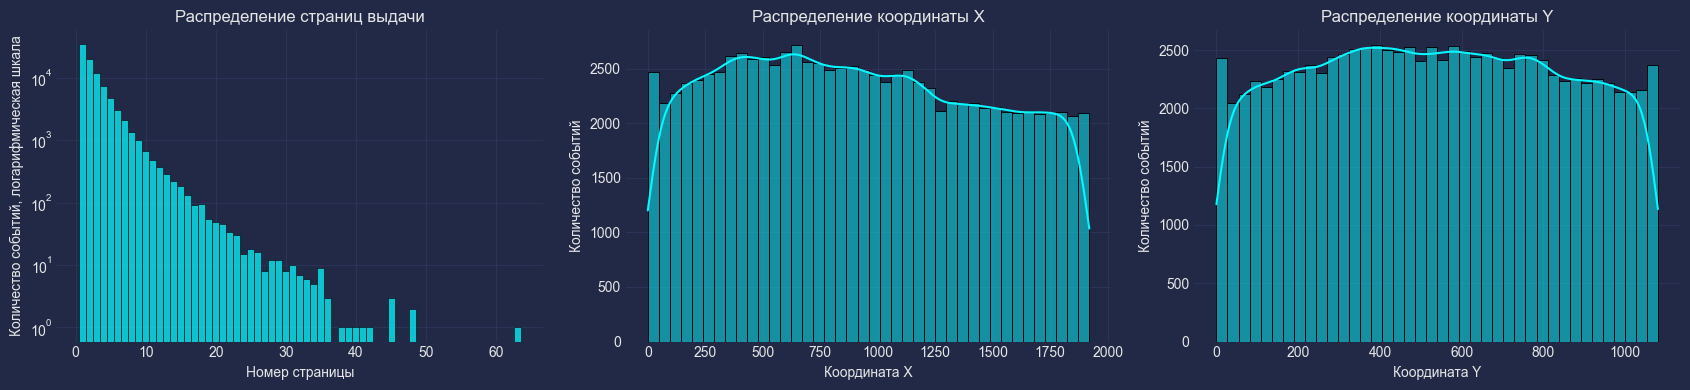

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.histplot(
    data=events_clean,
    x="search_page",
    discrete=True,
    ax=axes[0],
)
axes[0].set_title("Распределение страниц выдачи")
axes[0].set_xlabel("Номер страницы")
axes[0].set_yscale("log")
axes[0].set_ylabel("Количество событий, логарифмическая шкала")

sns.histplot(
    data=events_clean,
    x="pointer_x",
    bins=40,
    ax=axes[1],
    kde=True
)
axes[1].set_title("Распределение координаты X")
axes[1].set_xlabel("Координата X")
axes[1].set_ylabel("Количество событий")

sns.histplot(
    data=events_clean,
    x="pointer_y",
    bins=40,
    ax=axes[2],
    kde=True
)
axes[2].set_title("Распределение координаты Y")
axes[2].set_xlabel("Координата Y")
axes[2].set_ylabel("Количество событий")

plt.tight_layout()
plt.show()

### Проверка времени создания куки

In [29]:
cookie_created = pd.concat(
    [
        train[["cookie_id", "cookie_created_at"]],
        test[["cookie_id", "cookie_created_at"]],
    ],
    ignore_index=True,
)

first_events = (
    events_clean.groupby("cookie_id")["event_ts"]
    .min()
    .rename("first_event_ts")
    .reset_index()
)

creation_check = first_events.merge(
    cookie_created,
    on="cookie_id",
    how="left",
)

creation_check["days_since_creation"] = (
    creation_check["first_event_ts"]
    - creation_check["cookie_created_at"]
).dt.total_seconds() / 86400

In [30]:
events_before_creation = creation_check.loc[
    creation_check["days_since_creation"] < 0
]

print(
    "Куки с событиями раньше времени создания:",
    len(events_before_creation),
)

display(events_before_creation.head())

Куки с событиями раньше времени создания: 0


,cookie_id,first_event_ts,cookie_created_at,days_since_creation


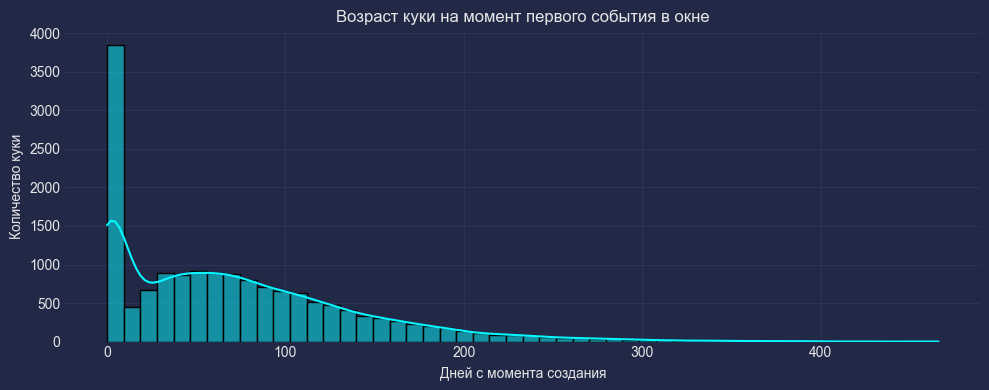

In [31]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=creation_check,
    x="days_since_creation",
    bins=50,
    kde=True
)

plt.title("Возраст куки на момент первого события в окне")
plt.xlabel("Дней с момента создания")
plt.ylabel("Количество куки")
plt.tight_layout()
plt.show()

### Количество событий на куку после очистки

In [32]:
cookie_meta = pd.concat(
    [
        train[["cookie_id"]].assign(dataset="train"),
        test[["cookie_id"]].assign(dataset="test"),
    ],
    ignore_index=True,
)

event_counts = (
    events_clean.groupby("cookie_id")
    .size()
    .rename("n_events")
    .reset_index()
)

cookie_activity = cookie_meta.merge(
    event_counts,
    on="cookie_id",
    how="left",
)

cookie_activity["n_events"] = (
    cookie_activity["n_events"]
    .fillna(0)
    .astype(int)
)

In [33]:
for name, group in cookie_activity.groupby("dataset"):
    print(
        f"{name}: куки без событий — "
        f"{group['n_events'].eq(0).sum()}"
    )

test: куки без событий — 0
train: куки без событий — 0


In [34]:
display(
    cookie_activity.groupby("dataset")["n_events"]
    .describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99])
    .round(2)
)

,count,mean,std,min,1%,10%,50%,90%,99%,max
dataset,,,,,,,,,,
test,4909.0,18.00,18.37,1.0,1.0,3.0,12.0,39.0,91.0,187.0
train,11091.0,17.63,17.44,1.0,1.0,3.0,12.0,39.0,86.0,165.0


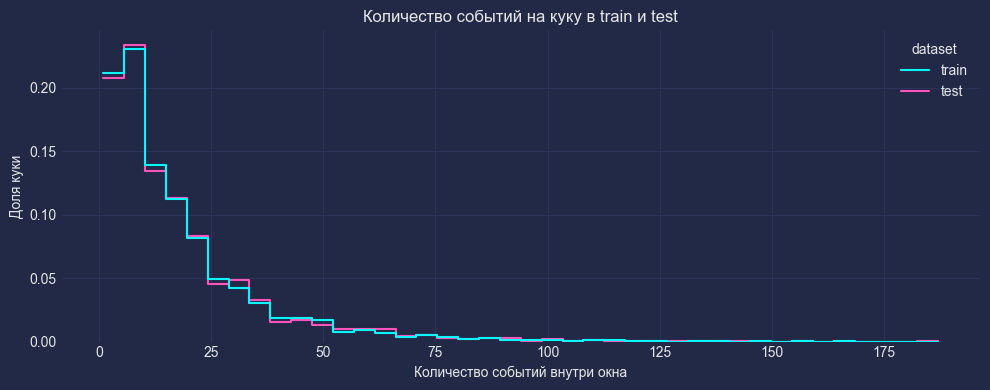

In [35]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=cookie_activity,
    x="n_events",
    hue="dataset",
    bins=40,
    stat="probability",
    common_norm=False,
    element="step",
    fill=False,
)

plt.title("Количество событий на куку в train и test")
plt.xlabel("Количество событий внутри окна")
plt.ylabel("Доля куки")
plt.tight_layout()
plt.show()

In [36]:
activity_groups = pd.cut(
    cookie_activity["n_events"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["Нет событий", "1 событие", "2 события", "3 и более"],
)

activity_summary = (
    pd.crosstab(
        cookie_activity["dataset"],
        activity_groups,
        normalize="index",
    )
    .mul(100)
    .reindex(
        columns=["Нет событий", "1 событие", "2 события", "3 и более"],
        fill_value=0,
    )
)

display(activity_summary.round(2))

n_events,Нет событий,1 событие,2 события,3 и более
dataset,,,,
test,0,2.14,4.01,93.85
train,0,2.29,3.56,94.15


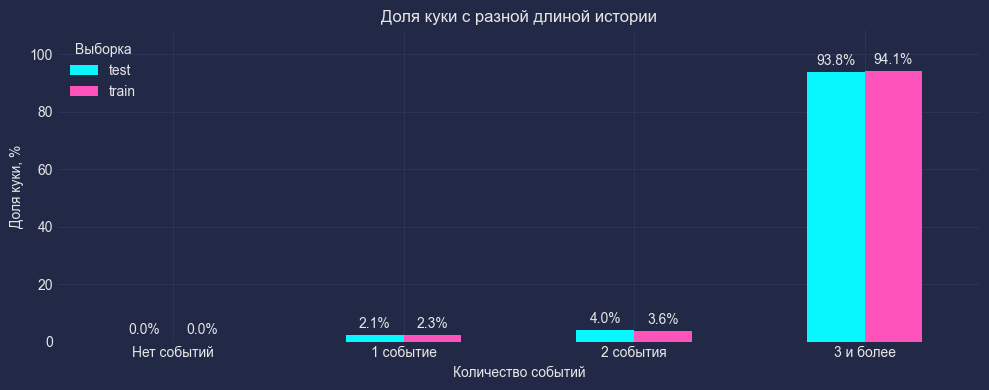

In [37]:
ax = activity_summary.T.plot(
    kind="bar",
    figsize=(10, 4),
    rot=0,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_title("Доля куки с разной длиной истории")
ax.set_xlabel("Количество событий")
ax.set_ylabel("Доля куки, %")
ax.legend(title="Выборка")
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

### Вывод

Удалены 4863 полных дубликата исходных событий и 40 209 событий за пределами окна. Для построения признаков осталось 283 833 события. У каждой куки есть хотя бы одно событие внутри окна. Пропуски зависят от типа события и платформы. Поэтому общей замены пропусков на нули не делал. Статистики считал по доступным значениям, а отсутствие наблюдений сохранял.

## Построение признаков

### Базовые признаки

In [38]:
# Признаки считал отдельно для каждой куки, target в общую таблицу не добавлял
meta_columns = [
    "cookie_id",
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

features = (
    pd.concat(
        [train[meta_columns], test[meta_columns]],
        ignore_index=True,
    )
    .set_index("cookie_id")
)

features.head()

,cookie_created_at,window_start_ts,window_end_ts
cookie_id,,,
ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07
ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07
ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07
ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07
ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07


In [39]:
features["n_events"] = (
    events_clean.groupby("cookie_id").size()
)

features["n_events"] = (
    features["n_events"].fillna(0).astype(int)
)

In [40]:
event_types = [
    "search_results_view",
    "item_view",
    "photo_swipe",
    "seller_page_view",
    "contact_phone_show",
    "contact_chat_open",
    "contact_message_sent",
    "favorite_add",
    "login",
]

event_type_counts = pd.crosstab(
    events_clean["cookie_id"],
    events_clean["event_name"],
)

event_type_counts = (
    event_type_counts
    .reindex(
        index=features.index,
        columns=event_types,
        fill_value=0,
    )
    .add_prefix("count_")
)

event_type_counts.columns.name = None

count_columns = event_type_counts.columns.tolist()

features[count_columns] = event_type_counts

display(features[count_columns].head())

,count_search_results_view,count_item_view,count_photo_swipe,count_seller_page_view,count_contact_phone_show,count_contact_chat_open,count_contact_message_sent,count_favorite_add,count_login
cookie_id,,,,,,,,,
ck_54a059eb7d3ea68b,3,3,1,0,0,0,0,0,0
ck_7e4de46eeab82974,8,22,4,4,1,0,0,1,1
ck_9320229ef6304522,13,7,3,3,2,1,1,3,3
ck_30ccd25bc1714ed9,3,14,0,2,1,1,0,0,0
ck_a77c5f05948cdeef,6,12,4,3,1,0,0,2,0


In [41]:
share_columns = [
    f"share_{event_type}"
    for event_type in event_types
]

event_type_shares = features[count_columns].div(
    features["n_events"].where(features["n_events"] > 0),
    axis=0,
)

event_type_shares.columns = share_columns

features[share_columns] = event_type_shares

display(features[share_columns].head())

,share_search_results_view,share_item_view,share_photo_swipe,share_seller_page_view,share_contact_phone_show,share_contact_chat_open,share_contact_message_sent,share_favorite_add,share_login
cookie_id,,,,,,,,,
ck_54a059eb7d3ea68b,0.428571,0.428571,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ck_7e4de46eeab82974,0.195122,0.536585,0.097561,0.097561,0.024390,0.000000,0.000000,0.024390,0.024390
ck_9320229ef6304522,0.361111,0.194444,0.083333,0.083333,0.055556,0.027778,0.027778,0.083333,0.083333
ck_30ccd25bc1714ed9,0.142857,0.666667,0.000000,0.095238,0.047619,0.047619,0.000000,0.000000,0.000000
ck_a77c5f05948cdeef,0.214286,0.428571,0.142857,0.107143,0.035714,0.000000,0.000000,0.071429,0.000000


In [42]:
item_views = events_clean.loc[
    events_clean["event_name"] == "item_view"
]

features["n_unique_items_viewed"] = (
    item_views.groupby("cookie_id")["item_id"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

known_item_view_counts = (
    item_views.groupby("cookie_id")["item_id"]
    .count()
    .reindex(features.index, fill_value=0)
)

features["unique_item_view_ratio"] = (
    features["n_unique_items_viewed"]
    / known_item_view_counts.where(known_item_view_counts > 0)
)

In [43]:
# Возраст куки считаем на момент окончания окна
features["cookie_age_days"] = (
    features["window_end_ts"]
    - features["cookie_created_at"]
).dt.total_seconds() / 86400

features["created_in_window"] = (
    (features["cookie_created_at"] >= features["window_start_ts"])
    & (features["cookie_created_at"] < features["window_end_ts"])
).astype(int)

In [44]:
basic_feature_columns = [
    "n_events",
    *count_columns,
    *share_columns,
    "n_unique_items_viewed",
    "unique_item_view_ratio",
    "cookie_age_days",
    "created_in_window",
]

print("Количество куки:", len(features))
print("Количество базовых признаков:", len(basic_feature_columns))

display(features[basic_feature_columns].head())

Количество куки: 16000
Количество базовых признаков: 23


,n_events,count_search_results_view,count_item_view,count_photo_swipe,count_seller_page_view,count_contact_phone_show,count_contact_chat_open,count_contact_message_sent,count_favorite_add,count_login,...,share_seller_page_view,share_contact_phone_show,share_contact_chat_open,share_contact_message_sent,share_favorite_add,share_login,n_unique_items_viewed,unique_item_view_ratio,cookie_age_days,created_in_window
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,7,3,3,1,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,1.000000,136.603692,0
ck_7e4de46eeab82974,41,8,22,4,4,1,0,0,1,1,...,0.097561,0.024390,0.000000,0.000000,0.024390,0.024390,14,0.636364,195.576111,0
ck_9320229ef6304522,36,13,7,3,3,2,1,1,3,3,...,0.083333,0.055556,0.027778,0.027778,0.083333,0.083333,6,0.857143,33.994421,0
ck_30ccd25bc1714ed9,21,3,14,0,2,1,1,0,0,0,...,0.095238,0.047619,0.047619,0.000000,0.000000,0.000000,9,0.642857,1.546759,0
ck_a77c5f05948cdeef,28,6,12,4,3,1,0,0,2,0,...,0.107143,0.035714,0.000000,0.000000,0.071429,0.000000,12,1.000000,95.837095,0


In [45]:
train_features = train.merge(
    features[basic_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[basic_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

print("Train:", train_features.shape)
print("Test:", test_features.shape)

Train: (11091, 28)
Test: (4909, 27)


### Временное разбиение

In [46]:
fit_mask = (train_features["window_start_ts"] < pd.Timestamp("2026-04-13"))

valid_mask = ((train_features["window_start_ts"] >= pd.Timestamp("2026-04-13"))& (train_features["window_start_ts"] < pd.Timestamp("2026-04-17")))

holdout_mask = (train_features["window_start_ts"] >= pd.Timestamp("2026-04-17"))

split_summary = pd.DataFrame({
    "Количество куки": [
        fit_mask.sum(),
        valid_mask.sum(),
        holdout_mask.sum(),
    ],
    "Количество ботов": [
        train_features.loc[fit_mask, "target"].sum(),
        train_features.loc[valid_mask, "target"].sum(),
        train_features.loc[holdout_mask, "target"].sum(),
    ],
}, index=["Обучение", "Валидация", "Отложенная проверка"])

display(split_summary)

,Количество куки,Количество ботов
Обучение,5930,491
Валидация,3210,248
Отложенная проверка,1951,160


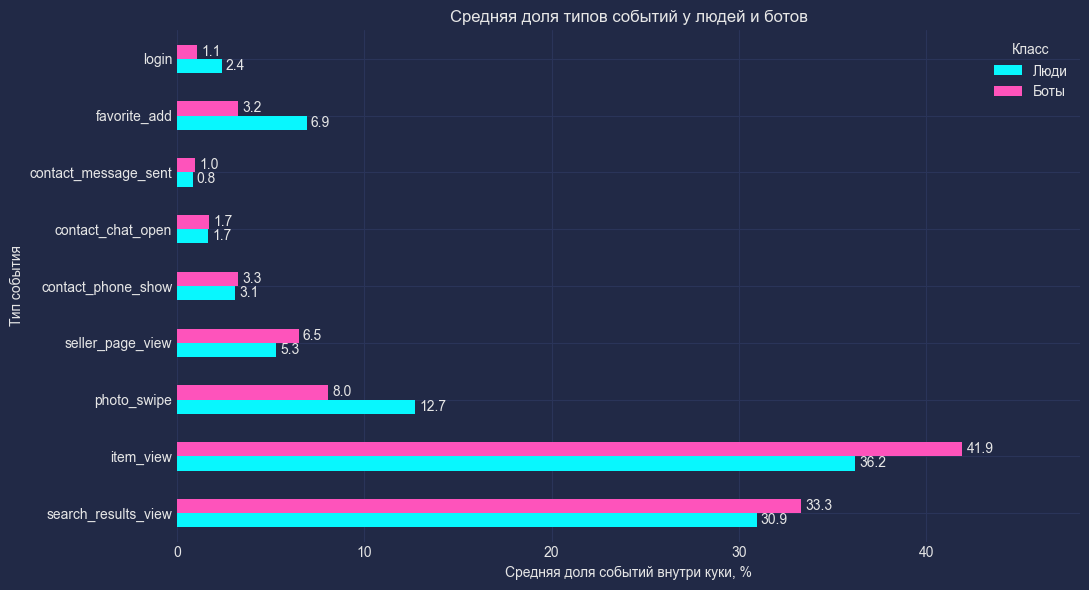

In [47]:
mean_event_shares = (
    train_features.loc[fit_mask]
    .groupby("target")[share_columns]
    .mean()
    .T
    .mul(100)
)

mean_event_shares.index = event_types

mean_event_shares = mean_event_shares.rename(
    columns={0: "Люди", 1: "Боты"}
)

ax = mean_event_shares.plot(
    kind="barh",
    figsize=(11, 6),
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

ax.set_title("Средняя доля типов событий у людей и ботов")
ax.set_xlabel("Средняя доля событий внутри куки, %")
ax.set_ylabel("Тип события")
ax.legend(title="Класс")
ax.margins(x=0.15)

plt.tight_layout()
plt.show()

## Обучение моделей

### Сравнение моделей на базовых признаках

In [48]:
X_train = train_features.loc[fit_mask, basic_feature_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, basic_feature_columns]
y_valid = train_features.loc[valid_mask, "target"]

print("Обучение:", X_train.shape)
print("Валидация:", X_valid.shape)

Обучение: (5930, 23)
Валидация: (3210, 23)


In [49]:
results = []
trained_models = {}
valid_predictions = {}


def evaluate_model(name, model, columns):
    start = perf_counter()

    model.fit(X_train[columns], y_train)

    scores = model.predict_proba(X_valid[columns])[:, 1]

    result = {
        "Эксперимент": name,
        "Признаков": len(columns),
        "P@R≥0.7": precision_at_recall(y_valid, scores),
        "Average Precision": average_precision_score(y_valid, scores),
        "ROC-AUC": roc_auc_score(y_valid, scores),
        "Время, сек": perf_counter() - start,
    }

    results.append(result)
    trained_models[name] = model
    valid_predictions[name] = scores

    display(pd.DataFrame([result]).round(4))

In [50]:
dummy = DummyClassifier(strategy="prior")

evaluate_model(
    name="Константный baseline",
    model=dummy,
    columns=["n_events"],
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,Константный baseline,1,0.0773,0.0773,0.5,0.0032


In [51]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

evaluate_model(
    name="RandomForest — 2 признака",
    model=rf_baseline,
    columns=["n_events", "n_unique_items_viewed"],
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,RandomForest — 2 признака,2,0.1,0.1665,0.6277,0.7398


In [52]:
logreg = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),
)

evaluate_model(
    name="LogReg — базовые признаки",
    model=logreg,
    columns=basic_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LogReg — базовые признаки,23,0.1993,0.4159,0.7994,0.0273


In [53]:
catboost_basic = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — базовые признаки",
    model=catboost_basic,
    columns=basic_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые признаки,23,0.1951,0.4648,0.8015,1.0911


In [54]:
results_table = (
    pd.DataFrame(results)
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

display(results_table.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LogReg — базовые признаки,23,0.1993,0.4159,0.7994,0.0273
1,CatBoost — базовые признаки,23,0.1951,0.4648,0.8015,1.0911
2,RandomForest — 2 признака,2,0.1000,0.1665,0.6277,0.7398
3,Константный baseline,1,0.0773,0.0773,0.5000,0.0032


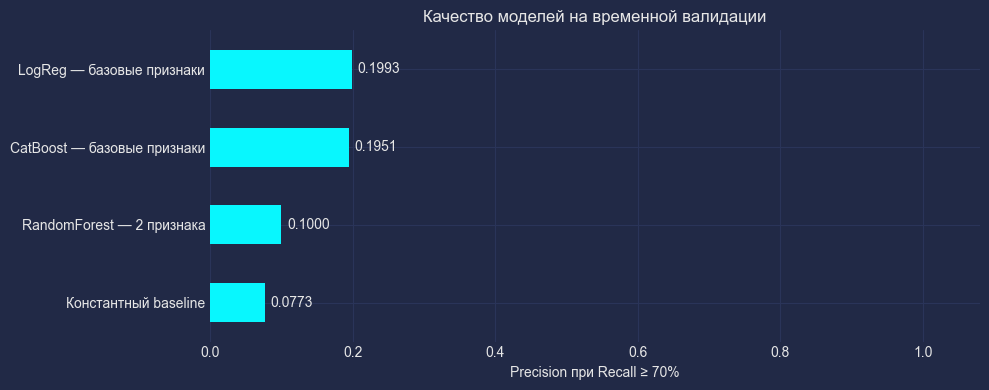

In [55]:
plot_results = results_table.sort_values("P@R≥0.7")

ax = plot_results.plot(
    x="Эксперимент",
    y="P@R≥0.7",
    kind="barh",
    figsize=(10, 4),
    legend=False,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Качество моделей на временной валидации")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

### Добавление временных признаков

Проверка, помогает ли информация об интервалах и регулярности действий отличать ботов от людей. Разбиение данных и параметры моделей сохранял.

In [56]:
# Первый интервал каждой куки остаётся пропуском
events_time = (
    events_clean[["cookie_id", "event_ts", "event_name"]]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

events_time["gap_seconds"] = (
    events_time.groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

display(events_time.head(10))

,cookie_id,event_ts,event_name,gap_seconds
0,ck_00013fdfa0bd37dd,2026-04-24 18:41:16,photo_swipe,NaN
1,ck_00013fdfa0bd37dd,2026-04-24 19:16:53,item_view,2137.0
2,ck_00013fdfa0bd37dd,2026-04-24 19:16:54,photo_swipe,1.0
3,ck_00013fdfa0bd37dd,2026-04-24 19:17:05,item_view,11.0
4,ck_00013fdfa0bd37dd,2026-04-24 20:05:05,login,2880.0
5,ck_00013fdfa0bd37dd,2026-04-24 20:31:33,item_view,1588.0
6,ck_00013fdfa0bd37dd,2026-04-24 20:34:06,search_results_view,153.0
7,ck_00013fdfa0bd37dd,2026-04-24 20:36:30,login,144.0
8,ck_00013fdfa0bd37dd,2026-04-24 20:36:32,contact_chat_open,2.0
9,ck_00013fdfa0bd37dd,2026-04-24 20:41:33,search_results_view,301.0


In [57]:
activity_times = (
    events_time.groupby("cookie_id")["event_ts"]
    .agg(["min", "max"])
)

time_features = pd.DataFrame(index=features.index)

time_features["activity_span_seconds"] = (
    activity_times["max"] - activity_times["min"]
).dt.total_seconds()

In [58]:
# Для std нужны хотя бы два интервала, при одном оставлял NaN
gap_stats = (
    events_time.groupby("cookie_id")["gap_seconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

gap_stats.columns = [
    "n_gaps",
    "gap_mean",
    "gap_median",
    "gap_std",
    "gap_min",
    "gap_max",
]

time_features[gap_stats.columns] = gap_stats

time_features["n_gaps"] = (time_features["n_gaps"].fillna(0).astype(int))

time_features["gap_cv"] = (time_features["gap_std"] / time_features["gap_mean"].where(time_features["gap_mean"] > 0))

In [59]:
valid_gaps = events_time.loc[
    events_time["gap_seconds"].notna(),
    ["cookie_id", "gap_seconds"],
].copy()

valid_gaps["gap_zero_share"] = valid_gaps["gap_seconds"].eq(0)
valid_gaps["gap_le_1s_share"] = valid_gaps["gap_seconds"].le(1)
valid_gaps["gap_le_5s_share"] = valid_gaps["gap_seconds"].le(5)
valid_gaps["gap_le_10s_share"] = valid_gaps["gap_seconds"].le(10)

gap_share_columns = [
    "gap_zero_share",
    "gap_le_1s_share",
    "gap_le_5s_share",
    "gap_le_10s_share",
]

gap_shares = (valid_gaps.groupby("cookie_id")[gap_share_columns].mean())

time_features[gap_share_columns] = gap_shares

In [60]:
item_times = events_time.loc[events_time["event_name"] == "item_view", ["cookie_id", "event_ts"],].copy()

item_times["gap_seconds"] = (
    item_times.groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

item_gap_stats = (
    item_times.groupby("cookie_id")["gap_seconds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

item_gap_stats.columns = [
    "n_item_gaps",
    "item_gap_mean",
    "item_gap_median",
    "item_gap_std",
    "item_gap_min",
    "item_gap_max",
]

time_features[item_gap_stats.columns] = item_gap_stats

time_features["n_item_gaps"] = (time_features["n_item_gaps"].fillna(0).astype(int))

time_features["item_gap_cv"] = (
    time_features["item_gap_std"]
    / time_features["item_gap_mean"].where(
        time_features["item_gap_mean"] > 0
    )
)

In [61]:
time_feature_columns = time_features.columns.tolist()

features[time_feature_columns] = time_features

extended_feature_columns = (basic_feature_columns + time_feature_columns)

print("Базовых признаков:", len(basic_feature_columns))
print("Временных признаков:", len(time_feature_columns))
print("Всего:", len(extended_feature_columns))

display(
    pd.DataFrame({
        "Пропуски": time_features.isna().sum(),
        "Доля пропусков, %": (
            time_features.isna().mean() * 100
        ).round(2),
    })
)

Базовых признаков: 23
Временных признаков: 19
Всего: 42


,Пропуски,"Доля пропусков, %"
activity_span_seconds,0,0.00
n_gaps,0,0.00
gap_mean,359,2.24
gap_median,359,2.24
gap_std,951,5.94
gap_min,359,2.24
gap_max,359,2.24
gap_cv,951,5.94
gap_zero_share,359,2.24
gap_le_1s_share,359,2.24


In [62]:
train_features = train.merge(
    features[extended_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[extended_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, extended_feature_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, extended_feature_columns]
y_valid = train_features.loc[valid_mask, "target"]

print("Обучение:", X_train.shape)
print("Валидация:", X_valid.shape)

Обучение: (5930, 42)
Валидация: (3210, 42)


In [63]:
logreg_time = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),
)

evaluate_model(
    name="LogReg — базовые + время",
    model=logreg_time,
    columns=extended_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LogReg — базовые + время,42,0.2091,0.486,0.8203,0.0461


In [64]:
catboost_time = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — базовые + время",
    model=catboost_time,
    columns=extended_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые + время,42,0.3107,0.6172,0.8616,1.3747


In [65]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Эксперимент", keep="last")
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

display(results_table.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые + время,42,0.3107,0.6172,0.8616,1.3747
1,LogReg — базовые + время,42,0.2091,0.4860,0.8203,0.0461
2,LogReg — базовые признаки,23,0.1993,0.4159,0.7994,0.0273
3,CatBoost — базовые признаки,23,0.1951,0.4648,0.8015,1.0911
4,RandomForest — 2 признака,2,0.1000,0.1665,0.6277,0.7398
5,Константный baseline,1,0.0773,0.0773,0.5000,0.0032


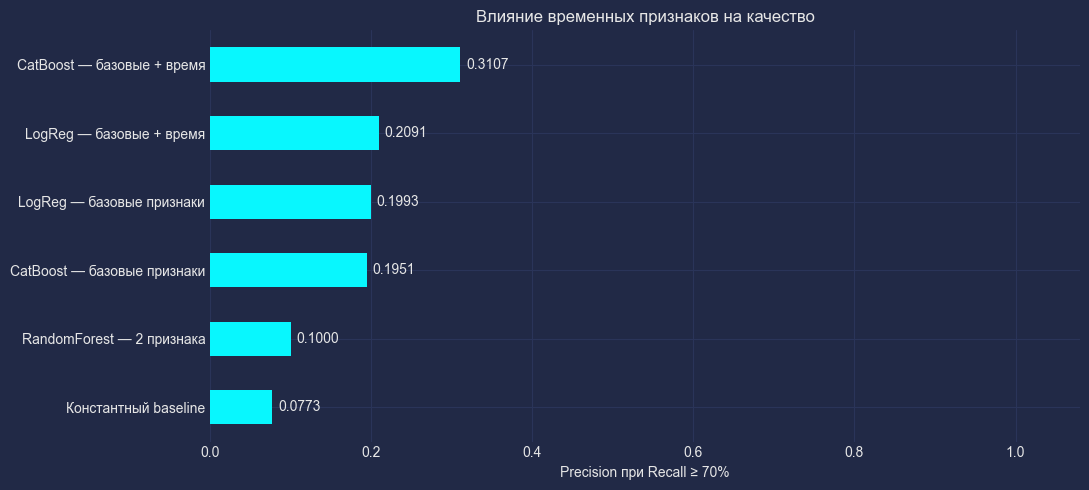

In [66]:
ax = (
    results_table
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(11, 5),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Влияние временных признаков на качество")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

**Вывод:**
Временные признаки улучшили качество обеих моделей на временной валидации. Наибольший прирост получен для CatBoost: P@R≥0.7 вырос с 0.1951 до 0.3107, Average Precision — с 0.4648 до 0.6172.

Результат показывает полезность информации о темпе и регулярности действий. Пропуски в статистиках интервалов сохранил, ибо они возникают при недостаточном числе событий и не означают нулевую длительность интервала.

Для следующих экспериментов использовал CatBoost с базовыми и временными признаками как точку сравнения. Holdout пока не использовал.

### Разнообразие просмотров и поисковое поведение

Проверка, помогает ли информация о разнообразии категорий, локаций и поисковых запросов, повторных просмотрах и глубине выдачи.

Признаки рассчитывал внутри окна каждой куки. Для сравнения сохранял разбиение данных и параметры CatBoost.

In [67]:
item_events = events_clean.loc[
    events_clean["event_name"].eq("item_view")
].copy()

diversity_features = pd.DataFrame(index=features.index)

item_group = item_events.groupby("cookie_id")

for column, feature_name in {
    "item_category": "n_unique_categories",
    "item_location": "n_unique_locations",
    "seller_type": "n_unique_seller_types",
}.items():
    diversity_features[feature_name] = (
        item_group[column]
        .nunique()
        .reindex(features.index, fill_value=0)
    )

known_item_views = (
    item_group["item_id"]
    .count()
    .reindex(features.index, fill_value=0)
)

unique_item_views = (
    item_group["item_id"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

diversity_features["n_repeat_item_views"] = (
    known_item_views - unique_item_views
)

display(diversity_features.head())

,n_unique_categories,n_unique_locations,n_unique_seller_types,n_repeat_item_views
cookie_id,,,,
ck_54a059eb7d3ea68b,2,3,2,0
ck_7e4de46eeab82974,1,8,2,8
ck_9320229ef6304522,4,2,2,1
ck_30ccd25bc1714ed9,1,4,2,5
ck_a77c5f05948cdeef,4,4,2,0


In [68]:
for column, feature_name in {
    "item_id": "top_item_share",
    "item_category": "top_category_share",
    "item_location": "top_location_share",
}.items():
    value_counts = (
        item_events
        .groupby(["cookie_id", column])
        .size()
    )

    top_count = value_counts.groupby(level=0).max()
    total_count = value_counts.groupby(level=0).sum()

    diversity_features[feature_name] = top_count / total_count

display(
    diversity_features[
        ["top_item_share", "top_category_share", "top_location_share"]
    ].describe()
)

,top_item_share,top_category_share,top_location_share
count,14964.000000,14840.000000,14903.000000
mean,0.396143,0.772403,0.596282
std,0.290788,0.231556,0.280016
min,0.026316,0.181818,0.090909
25%,0.176471,0.555556,0.333333
50%,0.333333,0.800000,0.500000
75%,0.500000,1.000000,0.857143
max,1.000000,1.000000,1.000000


In [69]:
search_events = events_clean.loc[
    events_clean["event_name"].eq("search_results_view")
].copy()

search_events["search_query"] = (
    search_events["search_query"].replace(r"^\s*$", np.nan, regex=True)
)

search_group = search_events.groupby("cookie_id")

diversity_features["n_unique_queries"] = (
    search_group["search_query"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

known_query_count = (
    search_group["search_query"]
    .count()
    .reindex(features.index, fill_value=0)
)

diversity_features["unique_query_ratio"] = (
    diversity_features["n_unique_queries"]
    / known_query_count.where(known_query_count > 0)
)

query_counts = (
    search_events
    .groupby(["cookie_id", "search_query"])
    .size()
)

diversity_features["top_query_share"] = (
    query_counts.groupby(level=0).max()
    / query_counts.groupby(level=0).sum()
)

page_stats = search_group["search_page"].agg(
    ["max", "mean", "nunique"]
)

page_stats.columns = [
    "search_page_max",
    "search_page_mean",
    "n_unique_search_pages",
]

diversity_features[page_stats.columns] = page_stats

diversity_features["n_unique_search_pages"] = (diversity_features["n_unique_search_pages"].fillna(0).astype(int))

known_pages = search_events.loc[
    search_events["search_page"].notna(),
    ["cookie_id", "search_page"],
].copy()

known_pages["beyond_first_page"] = known_pages["search_page"].gt(1)

diversity_features["search_beyond_first_page_share"] = (known_pages.groupby("cookie_id")["beyond_first_page"].mean())

In [70]:
diversity_feature_columns = diversity_features.columns.to_list()

features[diversity_feature_columns] = diversity_features

behavior_feature_columns = (extended_feature_columns + diversity_feature_columns)

print("Базовые + время:", len(extended_feature_columns))
print("Новые признаки:", len(diversity_feature_columns))
print("Всего:", len(behavior_feature_columns))

display(
    pd.DataFrame({
        "Пропуски": diversity_features.isna().sum(),
        "Доля пропусков, %": (
            diversity_features.isna().mean() * 100
        ).round(2),
    })
)

Базовые + время: 42
Новые признаки: 14
Всего: 56


,Пропуски,"Доля пропусков, %"
n_unique_categories,0,0.00
n_unique_locations,0,0.00
n_unique_seller_types,0,0.00
n_repeat_item_views,0,0.00
top_item_share,1036,6.48
top_category_share,1160,7.25
top_location_share,1097,6.86
n_unique_queries,0,0.00
unique_query_ratio,1356,8.48
top_query_share,1356,8.48


In [71]:
train_features = train.merge(
    features[behavior_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[behavior_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, behavior_feature_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, behavior_feature_columns]
y_valid = train_features.loc[valid_mask, "target"]

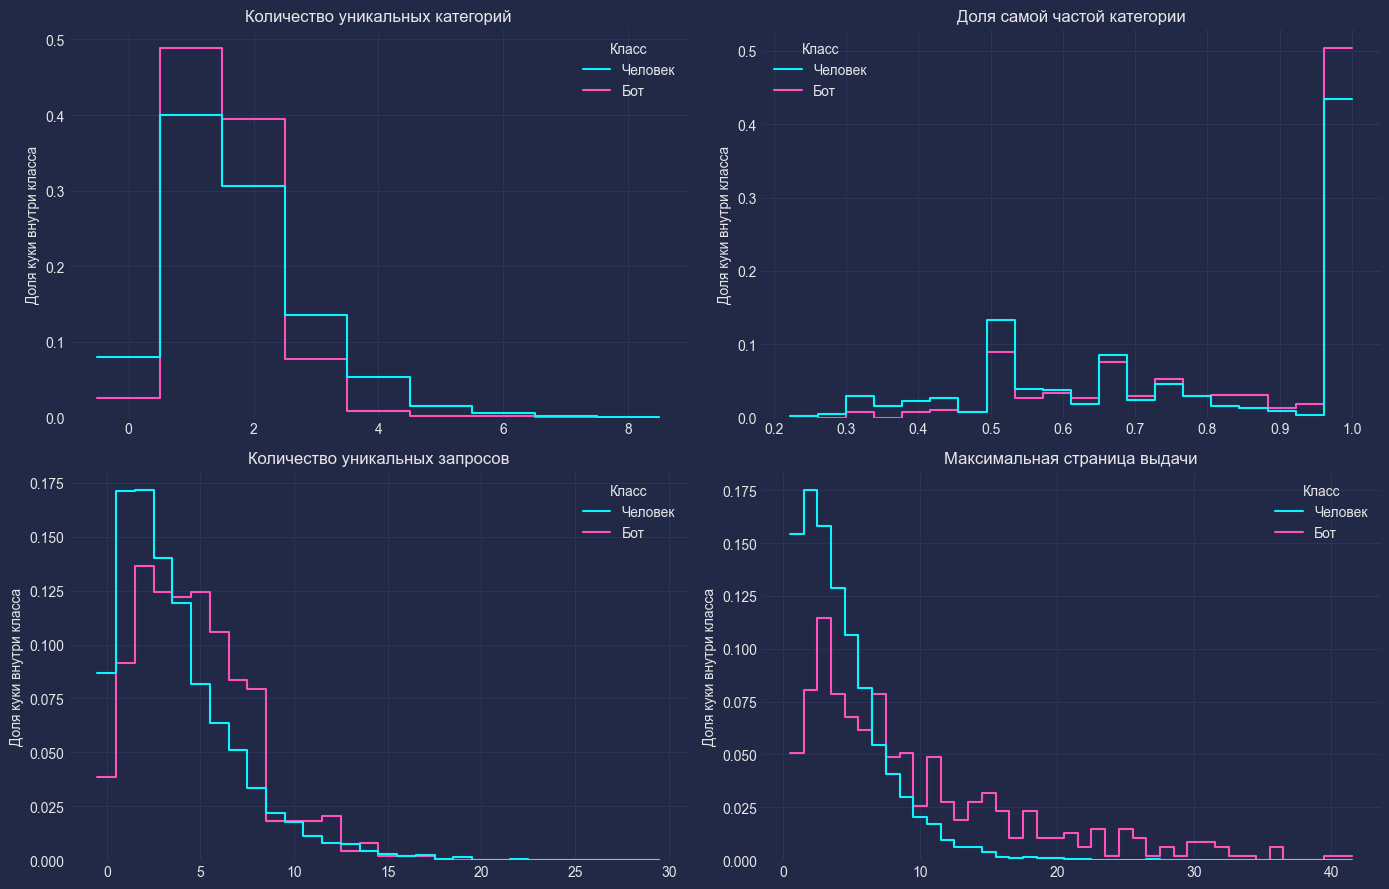

In [72]:
plot_data = train_features.loc[fit_mask].copy()

plot_data["Класс"] = plot_data["target"].map({
    0: "Человек",
    1: "Бот",
})

plot_settings = [
    ("n_unique_categories", "Количество уникальных категорий", True),
    ("top_category_share", "Доля самой частой категории", False),
    ("n_unique_queries", "Количество уникальных запросов", True),
    ("search_page_max", "Максимальная страница выдачи", True),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (column, title, discrete) in zip(
    axes.flat, plot_settings
):
    sns.histplot(
        data=plot_data,
        x=column,
        hue="Класс",
        hue_order=["Человек", "Бот"],
        stat="probability",
        common_norm=False,
        element="step",
        fill=False,
        discrete=discrete,
        bins=20,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Доля куки внутри класса")

plt.tight_layout()
plt.show()

In [73]:
catboost_behavior = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — базовые + время + разнообразие",
    model=catboost_behavior,
    columns=behavior_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые + время + разнообразие,56,0.3937,0.6496,0.8697,1.6296


In [74]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Эксперимент", keep="last")
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

display(results_table.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые + время + разнообразие,56,0.3937,0.6496,0.8697,1.6296
1,CatBoost — базовые + время,42,0.3107,0.6172,0.8616,1.3747
2,LogReg — базовые + время,42,0.2091,0.4860,0.8203,0.0461
3,LogReg — базовые признаки,23,0.1993,0.4159,0.7994,0.0273
4,CatBoost — базовые признаки,23,0.1951,0.4648,0.8015,1.0911
5,RandomForest — 2 признака,2,0.1000,0.1665,0.6277,0.7398
6,Константный baseline,1,0.0773,0.0773,0.5000,0.0032


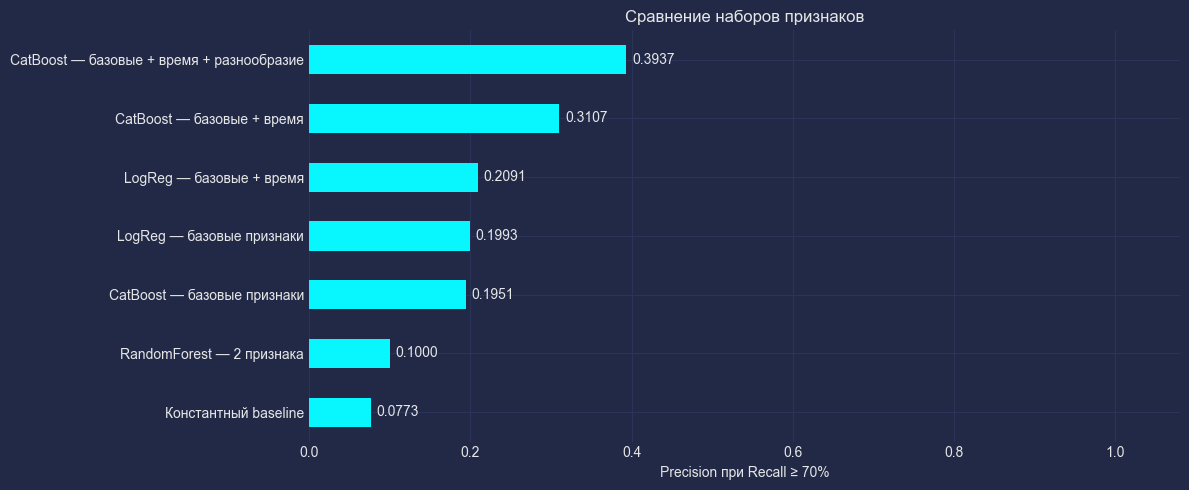

In [75]:
ax = (
    results_table
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(12, 5),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Сравнение наборов признаков")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

#### Вывод

Добавление разнообразия просмотров и поискового поведения повысило
P@R≥0.7 с 0.3107 до 0.3937. Average Precision и ROC-AUC также выросли.

На обучающей части у ботов чаще встречается просмотр одной категории
и более глубоких страниц выдачи. Распределения классов пересекаются,
поэтому эти признаки полезно рассматривать совместно с временными
характеристиками и составом действий.

Текущий лучший результат получен CatBoost на 56 признаках.
Устойчивость улучшения ещё предстоит проверить на другом временном периоде.

### Признаки User-Agent

Из User-Agent извлекал семейства браузеров и операционных систем, маркеры автоматизированных клиентов и разнообразие UA внутри куки.

В этом эксперименте использовал обобщённые характеристики UA без кодирования конкретных строк. Разбор выполнял локально простыми правилами, такие правила могут не распознать отдельные клиенты, а сам User-Agent может быть подменён.

Проверял пользу нового блока относительно CatBoost на 56 признаках.

In [76]:
ua_events = events_clean[["cookie_id", "user_agent"]].copy()

ua_events["ua_normalized"] = (
    ua_events["user_agent"]
    .fillna("")
    .str.strip()
    .str.lower()
)

ua = ua_events["ua_normalized"]

ua_events["ua_missing"] = ua.eq("")

ua_events["ua_headless"] = ua.str.contains(
    r"headless|phantomjs|selenium|playwright|puppeteer",
    regex=True,
)

ua_events["ua_http_client"] = ua.str.contains(
    r"python-requests|python-urllib|aiohttp|httpx|"
    r"curl/|wget/|scrapy|go-http-client|"
    r"apache-httpclient|libwww-perl",
    regex=True,
)

ua_events["ua_crawler_marker"] = ua.str.contains(
    r"bot|crawler|spider",
    regex=True,
)

In [77]:
ua_events["browser_family"] = np.select(
    [
        ua.eq(""),
        ua.str.contains(r"edg/|edga/|edgios/", regex=True),
        ua.str.contains(r"opr/|opera", regex=True),
        ua.str.contains("yabrowser", regex=False),
        ua.str.contains("samsungbrowser", regex=False),
        ua.str.contains(r"firefox/|fxios/", regex=True),
        ua.str.contains(r"chrome/|crios/|chromium/", regex=True),
        ua.str.contains("safari/", regex=False),
    ],
    [
        "missing",
        "edge",
        "opera",
        "yandex",
        "samsung",
        "firefox",
        "chrome",
        "safari",
    ],
    default="other",
)

ua_events["os_family"] = np.select(
    [
        ua.eq(""),
        ua.str.contains("android", regex=False),
        ua.str.contains(r"iphone|ipad|ipod", regex=True),
        ua.str.contains("windows", regex=False),
        ua.str.contains(r"macintosh|mac os x", regex=True),
        ua.str.contains("linux", regex=False),
    ],
    [
        "missing",
        "android",
        "ios",
        "windows",
        "macos",
        "linux",
    ],
    default="other",
)

# Примеры разбора только для обучающей части
fit_cookie_ids = train_features.loc[fit_mask, "cookie_id"]

ua_examples = (
    ua_events.loc[
        ua_events["cookie_id"].isin(fit_cookie_ids),
        [
            "user_agent",
            "browser_family",
            "os_family",
            "ua_headless",
            "ua_http_client",
            "ua_crawler_marker",
        ],
    ]
    .drop_duplicates(subset="user_agent")
)

with pd.option_context("display.max_colwidth", 120):
    display(ua_examples.head(20))

,user_agent,browser_family,os_family,ua_headless,ua_http_client,ua_crawler_marker
31,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:116.0) Gecko/20100101 Firefox/116.0,firefox,windows,False,False,False
81,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 YaBrowser/23.8.0.0...",yandex,windows,False,False,False
155,"Mozilla/5.0 (Linux; Android 13; Redmi Note 11) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari...",chrome,android,False,False,False
237,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:111.0) Gecko/20100101 Firefox/111.0,firefox,windows,False,False,False
239,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:112.0) Gecko/20100101 Firefox/112.0,firefox,windows,False,False,False
302,"Mozilla/5.0 (Linux; Android 14; SM-G991B) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/118.0.0.0 Mobile Safari/537.36",chrome,android,False,False,False
490,"Mozilla/5.0 (Linux; Android 11; Redmi Note 11) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari...",chrome,android,False,False,False
588,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",chrome,macos,False,False,False
612,Avito/120.0 (Android 11; M2101K6G) okhttp/4.11.0,other,android,False,False,False
639,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",chrome,windows,False,False,False


In [78]:
ua_features = pd.DataFrame(index=features.index)

ua_flag_columns = [
    "ua_missing",
    "ua_headless",
    "ua_http_client",
    "ua_crawler_marker",
]

ua_flag_shares = (
    ua_events.groupby("cookie_id")[ua_flag_columns]
    .mean()
    .add_suffix("_share")
)

ua_features[ua_flag_shares.columns] = ua_flag_shares

browser_families = ["edge", "opera", "yandex", "samsung", "firefox", "chrome", "safari", "other",]

os_families = ["android", "ios", "windows", "macos", "linux", "other",]

for column, families, prefix in [
    ("browser_family", browser_families, "ua_browser"),
    ("os_family", os_families, "ua_os"),
]:
    for family in families:
        feature_name = f"{prefix}_{family}_share"

        ua_features[feature_name] = (
            ua_events[column]
            .eq(family)
            .groupby(ua_events["cookie_id"])
            .mean()
        )

known_ua_events = ua_events.loc[
    ~ua_events["ua_missing"]
]

ua_features["n_unique_ua"] = (
    known_ua_events.groupby("cookie_id")["ua_normalized"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

ua_features["n_browser_families"] = (
    known_ua_events.groupby("cookie_id")["browser_family"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

ua_features["n_os_families"] = (
    known_ua_events.groupby("cookie_id")["os_family"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

ua_feature_columns = ua_features.columns.to_list()

features[ua_feature_columns] = ua_features

ua_model_columns = behavior_feature_columns + ua_feature_columns

print("Предыдущих признаков:", len(behavior_feature_columns))
print("Признаков UA:", len(ua_feature_columns))
print("Всего:", len(ua_model_columns))

display(ua_features.head())

Предыдущих признаков: 56
Признаков UA: 21
Всего: 77


,ua_missing_share,ua_headless_share,ua_http_client_share,ua_crawler_marker_share,ua_browser_edge_share,ua_browser_opera_share,ua_browser_yandex_share,ua_browser_samsung_share,ua_browser_firefox_share,ua_browser_chrome_share,...,ua_browser_other_share,ua_os_android_share,ua_os_ios_share,ua_os_windows_share,ua_os_macos_share,ua_os_linux_share,ua_os_other_share,n_unique_ua,n_browser_families,n_os_families
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1,1,1
ck_7e4de46eeab82974,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,1
ck_9320229ef6304522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,1
ck_30ccd25bc1714ed9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,1
ck_a77c5f05948cdeef,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1,1


In [79]:
train_features = train.merge(
    features[ua_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[ua_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, ua_model_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, ua_model_columns]
y_valid = train_features.loc[valid_mask, "target"]

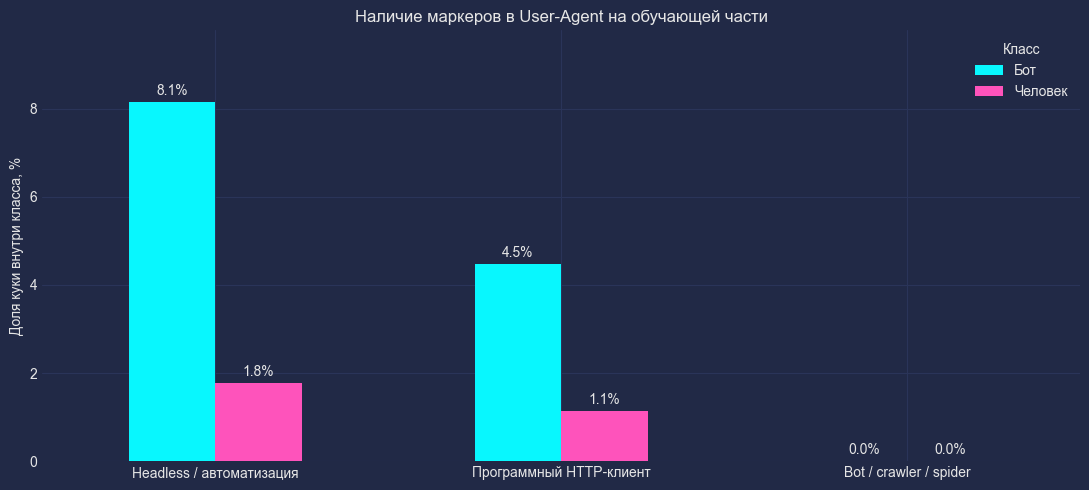

In [80]:
marker_columns = [
    "ua_headless_share",
    "ua_http_client_share",
    "ua_crawler_marker_share",
]

marker_presence = (
    train_features.loc[fit_mask, marker_columns]
    .gt(0)
)

marker_presence["Класс"] = (
    train_features.loc[fit_mask, "target"]
    .map({0: "Человек", 1: "Бот"})
)

marker_summary = (
    marker_presence.groupby("Класс")[marker_columns]
    .mean()
    .mul(100)
    .rename(columns={
        "ua_headless_share": "Headless / автоматизация",
        "ua_http_client_share": "Программный HTTP-клиент",
        "ua_crawler_marker_share": "Bot / crawler / spider",
    })
)

ax = marker_summary.T.plot(
    kind="bar",
    figsize=(11, 5),
    rot=0,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

ax.set_title("Наличие маркеров в User-Agent на обучающей части")
ax.set_xlabel("")
ax.set_ylabel("Доля куки внутри класса, %")
ax.legend(title="Класс")
ax.margins(y=0.2)

plt.tight_layout()
plt.show()

In [81]:
catboost_ua = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — поведение + UA",
    model=catboost_ua,
    columns=ua_model_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — поведение + UA,77,0.3747,0.649,0.8708,1.9144


In [82]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Эксперимент", keep="last")
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

display(results_table.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые + время + разнообразие,56,0.3937,0.6496,0.8697,1.6296
1,CatBoost — поведение + UA,77,0.3747,0.6490,0.8708,1.9144
2,CatBoost — базовые + время,42,0.3107,0.6172,0.8616,1.3747
3,LogReg — базовые + время,42,0.2091,0.4860,0.8203,0.0461
4,LogReg — базовые признаки,23,0.1993,0.4159,0.7994,0.0273
5,CatBoost — базовые признаки,23,0.1951,0.4648,0.8015,1.0911
6,RandomForest — 2 признака,2,0.1000,0.1665,0.6277,0.7398
7,Константный baseline,1,0.0773,0.0773,0.5000,0.0032


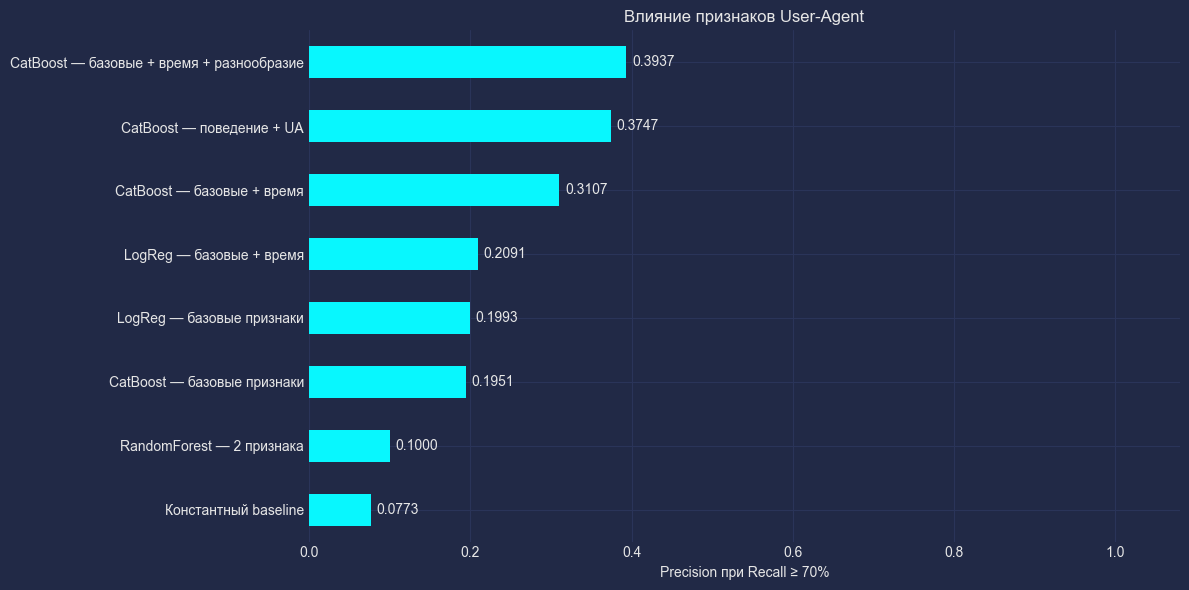

In [83]:
ax = (
    results_table
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(12, 6),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Влияние признаков User-Agent")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

### Поведение курсора

Добавление полного блока User-Agent снизило P@R≥0.7 с 0.3937 до 0.3747. Для следующего эксперимента использовал поведенческие признаки без UA. Проверил разнообразие и повторяемость координат курсора на web-платформе. В этом эксперименте проверял наличие координат и повторяемость позиций. Подробные статистики координат исследуются далее. Координаты записаны в моменты событий, поэтому их последовательность не является полной траекторией движения мыши.

In [84]:
web_events = (
    events_clean.loc[
        events_clean["platform"].eq("web"),
        ["cookie_id", "event_ts", "pointer_x", "pointer_y"],
    ]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

web_events["has_pointer"] = (web_events[["pointer_x", "pointer_y"]].notna().all(axis=1))

pointer_features = pd.DataFrame(index=features.index)

pointer_features["pointer_observed_share_web"] = (web_events.groupby("cookie_id")["has_pointer"].mean())

pointer_events = web_events.loc[web_events["has_pointer"]].copy()

pointer_features["n_pointer_observations"] = (
    pointer_events.groupby("cookie_id")
    .size()
    .reindex(features.index, fill_value=0)
)

In [85]:
point_counts = (
    pointer_events
    .groupby(["cookie_id", "pointer_x", "pointer_y"])
    .size()
)

unique_points = point_counts.groupby(level=0).size()
observed_points = point_counts.groupby(level=0).sum()

pointer_features["pointer_unique_ratio"] = (
    unique_points / observed_points
)

pointer_features["pointer_top_position_share"] = (
    point_counts.groupby(level=0).max() / observed_points
)

In [86]:
previous_pointer = (
    pointer_events.groupby("cookie_id")[
        ["event_ts", "pointer_x", "pointer_y"]
    ]
    .shift()
)

pointer_events["pointer_gap_seconds"] = (pointer_events["event_ts"] - previous_pointer["event_ts"]).dt.total_seconds()

pointer_events["same_x"] = (pointer_events["pointer_x"].eq(previous_pointer["pointer_x"]))

pointer_events["same_y"] = (pointer_events["pointer_y"].eq(previous_pointer["pointer_y"]))

pointer_events["same_position"] = (pointer_events["same_x"] & pointer_events["same_y"])

pointer_pairs = pointer_events.loc[pointer_events["pointer_gap_seconds"].gt(0)]

repeat_shares = (
    pointer_pairs.groupby("cookie_id")[
        ["same_x", "same_y", "same_position"]
    ]
    .mean()
    .rename(columns={
        "same_x": "pointer_same_x_share",
        "same_y": "pointer_same_y_share",
        "same_position": "pointer_same_position_share",
    })
)

pointer_features[repeat_shares.columns] = repeat_shares

display(
    pd.DataFrame({
        "Пропуски": pointer_features.isna().sum(),
        "Доля пропусков, %": (
            pointer_features.isna().mean() * 100
        ).round(2),
    })
)

,Пропуски,"Доля пропусков, %"
pointer_observed_share_web,7420,46.38
n_pointer_observations,0,0.00
pointer_unique_ratio,10139,63.37
pointer_top_position_share,10139,63.37
pointer_same_x_share,10312,64.45
pointer_same_y_share,10312,64.45
pointer_same_position_share,10312,64.45


In [87]:
pointer_feature_columns = pointer_features.columns.to_list()

features[pointer_feature_columns] = pointer_features

pointer_model_columns = (
    behavior_feature_columns + pointer_feature_columns
)

print("Поведенческих признаков:", len(behavior_feature_columns))
print("Признаков курсора:", len(pointer_feature_columns))
print("Всего:", len(pointer_model_columns))

Поведенческих признаков: 56
Признаков курсора: 7
Всего: 63


In [88]:
train_features = train.merge(
    features[pointer_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[pointer_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, pointer_model_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, pointer_model_columns]
y_valid = train_features.loc[valid_mask, "target"]

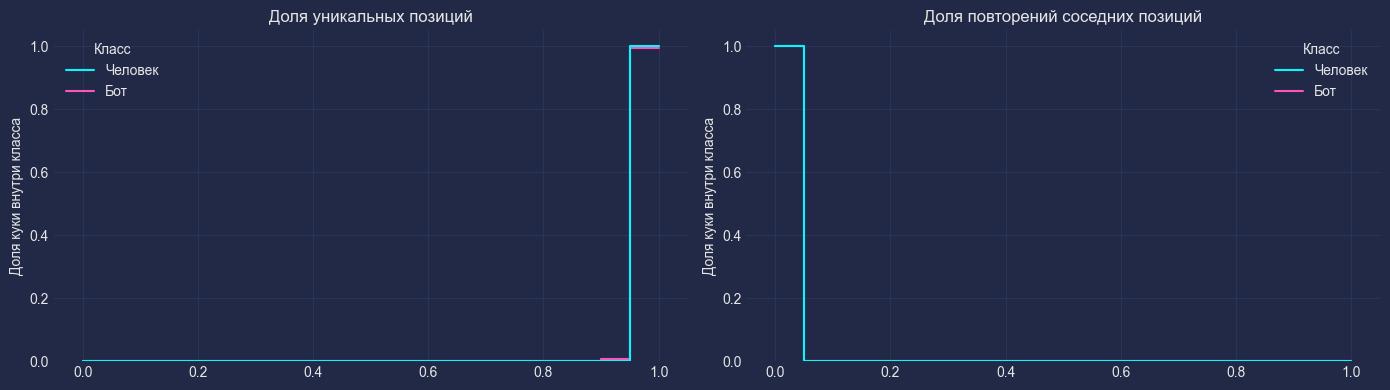

In [89]:
pointer_plot = train_features.loc[
    fit_mask & train_features["n_pointer_observations"].ge(3)
].copy()

pointer_plot["Класс"] = pointer_plot["target"].map({
    0: "Человек",
    1: "Бот",
})

plot_settings = [
    ("pointer_unique_ratio", "Доля уникальных позиций"),
    ("pointer_same_position_share", "Доля повторений соседних позиций"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (column, title) in zip(axes, plot_settings):
    sns.histplot(
        data=pointer_plot,
        x=column,
        hue="Класс",
        hue_order=["Человек", "Бот"],
        stat="probability",
        common_norm=False,
        bins=np.linspace(0, 1, 21),
        element="step",
        fill=False,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Доля куки внутри класса")

plt.tight_layout()
plt.show()

In [90]:
catboost_pointer = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — поведение + курсор",
    model=catboost_pointer,
    columns=pointer_model_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — поведение + курсор,63,0.3588,0.6449,0.8693,3.3089


In [91]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Эксперимент", keep="last")
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

display(results_table.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — базовые + время + разнообразие,56,0.3937,0.6496,0.8697,1.6296
1,CatBoost — поведение + UA,77,0.3747,0.6490,0.8708,1.9144
2,CatBoost — поведение + курсор,63,0.3588,0.6449,0.8693,3.3089
3,CatBoost — базовые + время,42,0.3107,0.6172,0.8616,1.3747
4,LogReg — базовые + время,42,0.2091,0.4860,0.8203,0.0461
5,LogReg — базовые признаки,23,0.1993,0.4159,0.7994,0.0273
6,CatBoost — базовые признаки,23,0.1951,0.4648,0.8015,1.0911
7,RandomForest — 2 признака,2,0.1000,0.1665,0.6277,0.7398
8,Константный baseline,1,0.0773,0.0773,0.5000,0.0032


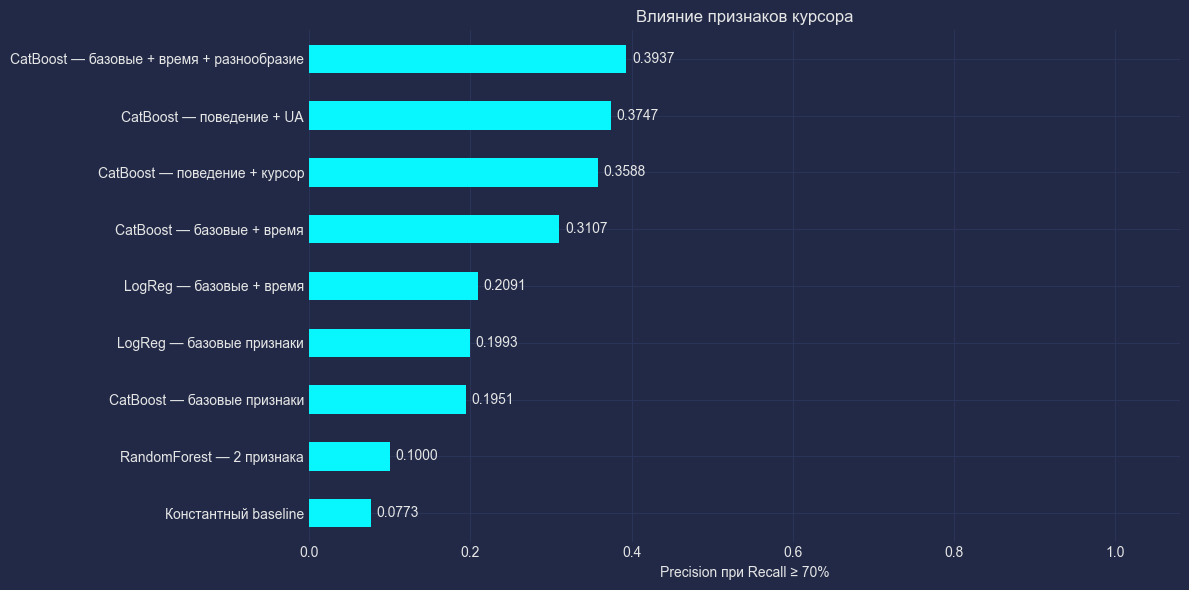

In [92]:
ax = (
    results_table
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(12, 6),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Влияние признаков курсора")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

### Устойчивость к случайности обучения

При random_seed=42 лучший результат получен на 56 поведенческих признаках. Добавление UA или координат курсора снизило основную метрику.

Сравнивал три набора на одинаковых пяти seed при неизменном временном разбиении и параметрах CatBoost. Дополнительно проверил усреднение предсказаний пяти моделей. Отдельный holdout пока не использовал.

In [93]:
feature_sets = {
    "Поведение": behavior_feature_columns,
    "Поведение + UA": ua_model_columns,
    "Поведение + курсор": pointer_model_columns,
}

comparison_columns = list(dict.fromkeys(
    column
    for columns in feature_sets.values()
    for column in columns
))

comparison_data = train.merge(
    features[comparison_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

comparison_y_train = comparison_data.loc[fit_mask, "target"]
comparison_y_valid = comparison_data.loc[valid_mask, "target"]

seeds = [42, 17, 73, 101, 2026]

seed_results = []
seed_predictions = {}
seed_models = {}

In [94]:
for name, columns in feature_sets.items():
    X_fit = comparison_data.loc[fit_mask, columns]
    X_val = comparison_data.loc[valid_mask, columns]

    seed_predictions[name] = []
    seed_models[name] = []

    for seed in seeds:
        model = CatBoostClassifier(
            iterations=600,
            depth=5,
            learning_rate=0.05,
            loss_function="Logloss",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=4,
        )

        model.fit(X_fit, comparison_y_train)
        scores = model.predict_proba(X_val)[:, 1]

        seed_predictions[name].append(scores)
        seed_models[name].append(model)

        metric = precision_at_recall(comparison_y_valid, scores)

        seed_results.append({
            "Набор": name,
            "Seed": seed,
            "P@R≥0.7": metric,
            "Average Precision": average_precision_score(
                comparison_y_valid, scores
            ),
            "ROC-AUC": roc_auc_score(
                comparison_y_valid, scores
            ),
        })

        print(f"{name}, seed={seed}: P@R≥0.7 = {metric:.4f}")

seed_results = pd.DataFrame(seed_results)

Поведение, seed=42: P@R≥0.7 = 0.3937
Поведение, seed=17: P@R≥0.7 = 0.4213
Поведение, seed=73: P@R≥0.7 = 0.3816
Поведение, seed=101: P@R≥0.7 = 0.3774
Поведение, seed=2026: P@R≥0.7 = 0.3480
Поведение + UA, seed=42: P@R≥0.7 = 0.3747
Поведение + UA, seed=17: P@R≥0.7 = 0.3968
Поведение + UA, seed=73: P@R≥0.7 = 0.3955
Поведение + UA, seed=101: P@R≥0.7 = 0.3686
Поведение + UA, seed=2026: P@R≥0.7 = 0.3758
Поведение + курсор, seed=42: P@R≥0.7 = 0.3588
Поведение + курсор, seed=17: P@R≥0.7 = 0.3774
Поведение + курсор, seed=73: P@R≥0.7 = 0.3640
Поведение + курсор, seed=101: P@R≥0.7 = 0.3633
Поведение + курсор, seed=2026: P@R≥0.7 = 0.3700


In [95]:
seed_summary = (
    seed_results.groupby("Набор")
    .agg(
        precision_mean=("P@R≥0.7", "mean"),
        precision_std=("P@R≥0.7", "std"),
        precision_min=("P@R≥0.7", "min"),
        precision_max=("P@R≥0.7", "max"),
        ap_mean=("Average Precision", "mean"),
        roc_auc_mean=("ROC-AUC", "mean"),
    )
    .sort_values("precision_mean", ascending=False)
)

display(seed_summary.round(4))

,precision_mean,precision_std,precision_min,precision_max,ap_mean,roc_auc_mean
Набор,,,,,,
Поведение,0.3844,0.0266,0.3480,0.4213,0.6505,0.8711
Поведение + UA,0.3823,0.0129,0.3686,0.3968,0.6556,0.8737
Поведение + курсор,0.3667,0.0072,0.3588,0.3774,0.6471,0.8717


Набор,Поведение,Поведение + UA,Поведение + курсор
Seed,,,
17,0.4213,0.3968,0.3774
42,0.3937,0.3747,0.3588
73,0.3816,0.3955,0.3640
101,0.3774,0.3686,0.3633
2026,0.3480,0.3758,0.3700


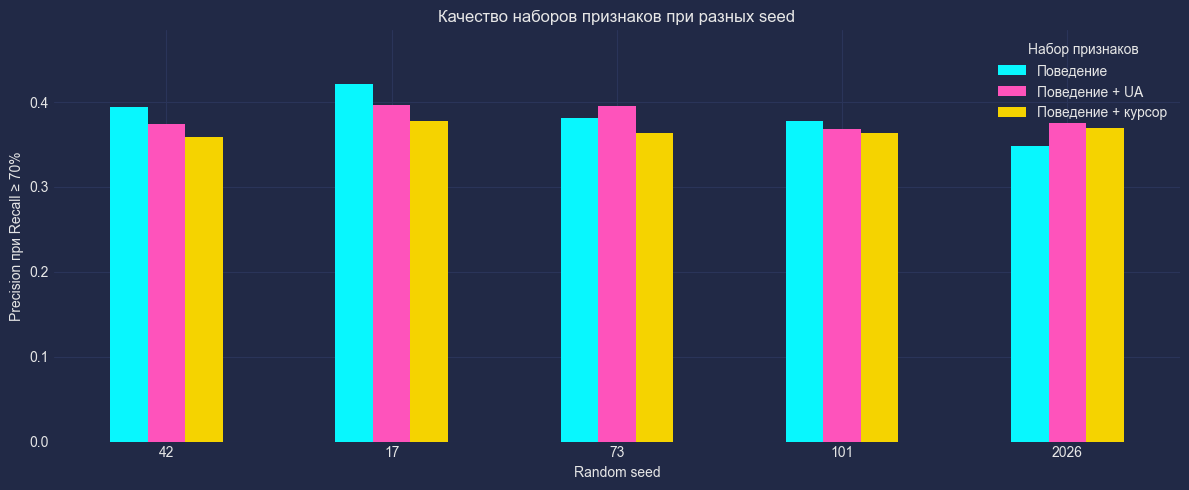

In [96]:
seed_pivot = seed_results.pivot(
    index="Seed",
    columns="Набор",
    values="P@R≥0.7",
)

display(seed_pivot.round(4))

ax = seed_pivot.reindex(seeds).plot(
    kind="bar",
    figsize=(12, 5),
    rot=0,
)

ax.set_title("Качество наборов признаков при разных seed")
ax.set_xlabel("Random seed")
ax.set_ylabel("Precision при Recall ≥ 70%")
ax.legend(title="Набор признаков")
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

In [97]:
ensemble_predictions = {}
ensemble_results = []

for name, predictions in seed_predictions.items():
    scores = np.mean(predictions, axis=0)

    ensemble_predictions[name] = scores

    ensemble_results.append({
        "Набор": name,
        "Моделей": len(predictions),
        "P@R≥0.7": precision_at_recall(
            comparison_y_valid, scores
        ),
        "Average Precision": average_precision_score(
            comparison_y_valid, scores
        ),
        "ROC-AUC": roc_auc_score(
            comparison_y_valid, scores
        ),
    })

ensemble_results = (
    pd.DataFrame(ensemble_results)
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

display(ensemble_results.round(4))

,Набор,Моделей,P@R≥0.7,Average Precision,ROC-AUC
0,Поведение,5,0.4047,0.6542,0.8727
1,Поведение + UA,5,0.3991,0.6592,0.8755
2,Поведение + курсор,5,0.3804,0.6505,0.8730


### LightGBM и расширенные временные признаки

Сравнивал LightGBM и CatBoost на одинаковых наборах признаков:
1. Текущие 56 поведенческих признаков.
2. Те же признаки с расширенными характеристиками времени.

Добавил квантили интервалов, доли коротких и длинных пауз, положение первого и последнего события внутри окна, распределение активности по часам от начала окна.

Временное разбиение сохранял. На этом этапе использовал фиксированные параметры и число итераций без early stopping.

In [98]:
lgbm_params = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "num_leaves": 15,
    "max_depth": -1,
    "min_child_samples": 30,
    "reg_lambda": 3.0,
    "random_state": RANDOM_STATE,
    "n_jobs": 4,
    "verbosity": -1,
    "deterministic": True,
    "force_col_wise": True,
}

In [99]:
train_features = train.merge(
    features[behavior_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, behavior_feature_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, behavior_feature_columns]
y_valid = train_features.loc[valid_mask, "target"]

lgbm_behavior = LGBMClassifier(**lgbm_params)

evaluate_model(
    name="LightGBM — поведение",
    model=lgbm_behavior,
    columns=behavior_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LightGBM — поведение,56,0.3028,0.6234,0.8547,0.7049


In [100]:
timing_extra = pd.DataFrame(index=features.index)

# events_time уже отсортирован по cookie_id и event_ts
gap_group = events_time.groupby("cookie_id")["gap_seconds"]

gap_quantiles = (
    gap_group
    .quantile([0.10, 0.25, 0.75, 0.90])
    .unstack()
)

gap_quantiles.columns = [
    "gap_q10",
    "gap_q25",
    "gap_q75",
    "gap_q90",
]

timing_extra[gap_quantiles.columns] = gap_quantiles

timing_extra["gap_iqr"] = (timing_extra["gap_q75"] - timing_extra["gap_q25"])

observed_gaps = events_time.loc[events_time["gap_seconds"].notna(),["cookie_id", "gap_seconds"],].copy()

observed_gaps["gap_le30s_share"] = (observed_gaps["gap_seconds"].le(30))

observed_gaps["gap_gt5min_share"] = (observed_gaps["gap_seconds"].gt(300))

observed_gaps["gap_gt30min_share"] = (observed_gaps["gap_seconds"].gt(1800))

extra_gap_columns = [
    "gap_le30s_share",
    "gap_gt5min_share",
    "gap_gt30min_share",
]

timing_extra[extra_gap_columns] = (observed_gaps.groupby("cookie_id")[extra_gap_columns].mean())

In [101]:
event_bounds = (
    events_time.groupby("cookie_id")["event_ts"]
    .agg(["min", "max"])
    .reindex(features.index)
)

timing_extra["first_event_offset_seconds"] = (
    event_bounds["min"] - features["window_start_ts"]
).dt.total_seconds()

timing_extra["last_event_to_end_seconds"] = (
    features["window_end_ts"] - event_bounds["max"]
).dt.total_seconds()

In [102]:
hour_events = events_clean[["cookie_id", "event_ts"]].copy()

hour_events["window_start_ts"] = (hour_events["cookie_id"].map(features["window_start_ts"]))

# Номер часа отсчитываем от начала окна
hour_events["window_hour"] = (
    (
        hour_events["event_ts"] - hour_events["window_start_ts"]
    )
    .dt.total_seconds()
    .floordiv(3600)
    .astype(int)
)

hour_counts = (
    pd.crosstab(
        hour_events["cookie_id"],
        hour_events["window_hour"],
    )
    .reindex(
        index=features.index,
        columns=range(24),
        fill_value=0,
    )
)

hour_totals = hour_counts.sum(axis=1)

hour_shares = hour_counts.div(
    hour_totals.where(hour_totals > 0),
    axis=0,
)

hour_share_columns = [
    f"window_hour_{hour:02d}_share"
    for hour in range(24)
]

timing_extra[hour_share_columns] = hour_shares.rename(columns=dict(zip(range(24), hour_share_columns)))

timing_extra["n_active_hours"] = hour_counts.gt(0).sum(axis=1)
timing_extra["hour_max_share"] = hour_shares.max(axis=1)

# Нулевые доли дают нулевой вклад в энтропию
entropy_terms = (hour_shares * np.log(hour_shares.where(hour_shares > 0)))

timing_extra["hour_entropy"] = (-entropy_terms.sum(axis=1) / np.log(24)).where(hour_totals > 0)

timing_extra_columns = timing_extra.columns.to_list()

features = pd.concat(
    [
        features.drop(columns=timing_extra_columns, errors="ignore"),
        timing_extra,
    ],
    axis=1,
).copy()

rich_time_columns = (behavior_feature_columns + timing_extra_columns)

print("Исходных признаков:", len(behavior_feature_columns))
print("Новых временных:", len(timing_extra_columns))
print("Всего:", len(rich_time_columns))

display(timing_extra.head())

Исходных признаков: 56
Новых временных: 37
Всего: 93


,gap_q10,gap_q25,gap_q75,gap_q90,gap_iqr,gap_le30s_share,gap_gt5min_share,gap_gt30min_share,first_event_offset_seconds,last_event_to_end_seconds,...,window_hour_17_share,window_hour_18_share,window_hour_19_share,window_hour_20_share,window_hour_21_share,window_hour_22_share,window_hour_23_share,n_active_hours,hour_max_share,hour_entropy
cookie_id,,,,,,,,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,3.5,9.50,31.00,59.0,21.50,0.666667,0.000000,0.000000,5487.0,80746.0,...,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.0,1,1.000000,-0.000000
ck_7e4de46eeab82974,6.9,19.00,82.25,3889.7,63.25,0.325000,0.150000,0.150000,39026.0,7898.0,...,0.04878,0.146341,0.0,0.097561,0.097561,0.0,0.0,8,0.292683,0.584339
ck_9320229ef6304522,4.8,14.50,73.00,4513.4,58.50,0.600000,0.200000,0.171429,4254.0,45655.0,...,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.0,7,0.277778,0.580173
ck_30ccd25bc1714ed9,17.9,37.25,70.00,877.9,32.75,0.250000,0.100000,0.100000,8850.0,60329.0,...,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.0,3,0.476190,0.314325
ck_a77c5f05948cdeef,28.6,32.50,106.50,2743.2,74.00,0.185185,0.148148,0.111111,29279.0,38023.0,...,0.00000,0.000000,0.0,0.000000,0.000000,0.0,0.0,5,0.642857,0.336369


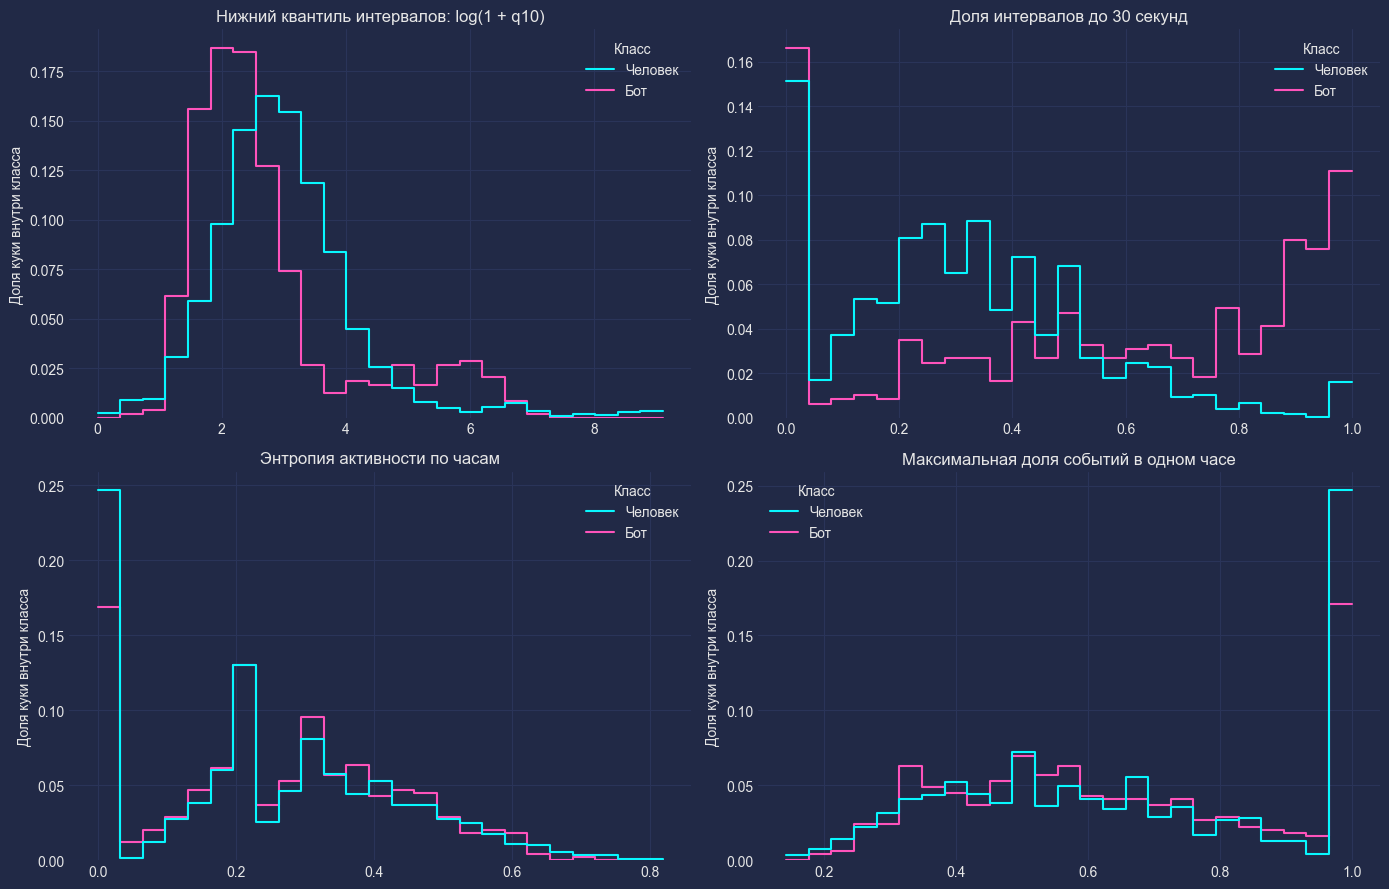

In [103]:
train_features = train.merge(
    features[rich_time_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[rich_time_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, rich_time_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, rich_time_columns]
y_valid = train_features.loc[valid_mask, "target"]

timing_plot = train_features.loc[fit_mask].copy()

timing_plot["Класс"] = timing_plot["target"].map({
    0: "Человек",
    1: "Бот",
})

timing_plot["log1p_gap_q10"] = np.log1p(timing_plot["gap_q10"])

plot_settings = [
    ("log1p_gap_q10", "Нижний квантиль интервалов: log(1 + q10)"),
    ("gap_le30s_share", "Доля интервалов до 30 секунд"),
    ("hour_entropy", "Энтропия активности по часам"),
    ("hour_max_share", "Максимальная доля событий в одном часе"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (column, title) in zip(axes.flat, plot_settings):
    sns.histplot(
        data=timing_plot,
        x=column,
        hue="Класс",
        hue_order=["Человек", "Бот"],
        stat="probability",
        common_norm=False,
        bins=25,
        element="step",
        fill=False,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Доля куки внутри класса")

plt.tight_layout()
plt.show()

In [104]:
lgbm_rich_time = LGBMClassifier(**lgbm_params)

evaluate_model(
    name="LightGBM — поведение + расширенный timing",
    model=lgbm_rich_time,
    columns=rich_time_columns,
)

catboost_rich_time = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — поведение + расширенный timing",
    model=catboost_rich_time,
    columns=rich_time_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LightGBM — поведение + расширенный timing,93,0.4028,0.6508,0.869,1.0028


,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — поведение + расширенный timing,93,0.4183,0.6704,0.8861,4.9601


In [105]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Эксперимент", keep="last")
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

timing_experiments = [
    "CatBoost — базовые + время + разнообразие",
    "LightGBM — поведение",
    "CatBoost — поведение + расширенный timing",
    "LightGBM — поведение + расширенный timing",
]

timing_comparison = results_table.loc[
    results_table["Эксперимент"].isin(timing_experiments)
].copy()

display(timing_comparison.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — поведение + расширенный timing,93,0.4183,0.6704,0.8861,4.9601
1,LightGBM — поведение + расширенный timing,93,0.4028,0.6508,0.8690,1.0028
2,CatBoost — базовые + время + разнообразие,56,0.3937,0.6496,0.8697,1.6296
6,LightGBM — поведение,56,0.3028,0.6234,0.8547,0.7049


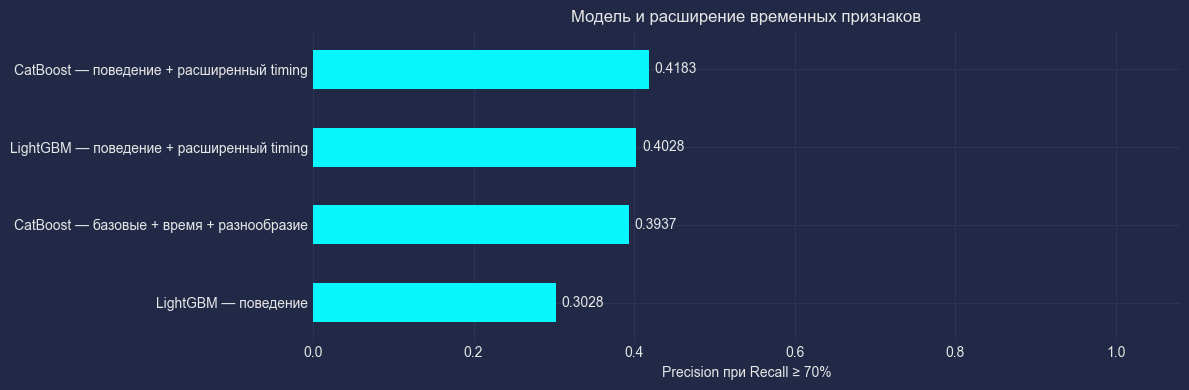

In [106]:
ax = (
    timing_comparison
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(12, 4),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Модель и расширение временных признаков")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

### Переходы между событиями

Добавил доли последовательных пар действий: например, item_view -> item_view или search_results_view -> item_view.

Переходы отбирал по распространённости только на обучающей части. Пары, затрагивающие события с неоднозначным порядком при одинаковом timestamp, исключал. Пропущенные пары же не соединял через соседние события.

Сравнивал модели с предыдущим набором из 93 признаков.

In [107]:
sequence_events = (
    events_clean[["cookie_id", "event_ts", "event_name"]]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

sequence_events["timestamp_unique"] = (
    sequence_events.groupby(["cookie_id", "event_ts"])["event_name"]
    .transform("size")
    .eq(1)
)

sequence_group = sequence_events.groupby("cookie_id")

sequence_events["previous_event"] = (sequence_group["event_name"].shift())

previous_unique = sequence_group["timestamp_unique"].shift()

valid_pair = (sequence_events["previous_event"].notna() & sequence_events["timestamp_unique"] & previous_unique.eq(True))

transitions = sequence_events.loc[
    valid_pair,
    ["cookie_id", "previous_event", "event_name"],
].copy()

transitions["transition"] = (
    transitions["previous_event"]
    + "__to__"
    + transitions["event_name"]
)

display(transitions.head(10))

,cookie_id,previous_event,event_name,transition
1,ck_00013fdfa0bd37dd,photo_swipe,item_view,photo_swipe__to__item_view
2,ck_00013fdfa0bd37dd,item_view,photo_swipe,item_view__to__photo_swipe
3,ck_00013fdfa0bd37dd,photo_swipe,item_view,photo_swipe__to__item_view
4,ck_00013fdfa0bd37dd,item_view,login,item_view__to__login
5,ck_00013fdfa0bd37dd,login,item_view,login__to__item_view
6,ck_00013fdfa0bd37dd,item_view,search_results_view,item_view__to__search_results_view
7,ck_00013fdfa0bd37dd,search_results_view,login,search_results_view__to__login
8,ck_00013fdfa0bd37dd,login,contact_chat_open,login__to__contact_chat_open
9,ck_00013fdfa0bd37dd,contact_chat_open,search_results_view,contact_chat_open__to__search_results_view
10,ck_00013fdfa0bd37dd,search_results_view,search_results_view,search_results_view__to__search_results_view


In [108]:
fit_cookie_ids = train.loc[fit_mask, "cookie_id"]

transition_support = (
    transitions.loc[
        transitions["cookie_id"].isin(fit_cookie_ids)
    ]
    .groupby("transition")["cookie_id"]
    .nunique()
    .sort_values(ascending=False)
)

selected_transitions = (
    transition_support.loc[transition_support >= 30]
    .index
    .sort_values()
    .to_list()
)

print("Отобрано переходов:", len(selected_transitions))

display(
    transition_support
    .head(15)
    .rename("Количество обучающих куки")
    .to_frame()
)

Отобрано переходов: 76


,Количество обучающих куки
transition,
search_results_view__to__item_view,4096
item_view__to__search_results_view,4063
item_view__to__item_view,3887
search_results_view__to__search_results_view,3403
item_view__to__photo_swipe,2569
photo_swipe__to__item_view,2516
photo_swipe__to__search_results_view,2275
search_results_view__to__photo_swipe,2240
favorite_add__to__item_view,1621


In [109]:
transition_counts = pd.crosstab(
    transitions["cookie_id"],
    transitions["transition"],
).reindex(
    index=features.index,
    columns=selected_transitions,
    fill_value=0,
)

n_valid_transitions = (
    transitions.groupby("cookie_id")
    .size()
    .reindex(features.index, fill_value=0)
)

transition_features = transition_counts.div(
    n_valid_transitions.where(n_valid_transitions > 0),
    axis=0,
).add_prefix("transition_share__")

transition_features.columns.name = None

transition_features["n_valid_transitions"] = n_valid_transitions

transition_feature_columns = transition_features.columns.to_list()

features = pd.concat(
    [
        features.drop(
            columns=transition_feature_columns,
            errors="ignore",
        ),
        transition_features,
    ],
    axis=1,
).copy()

sequence_feature_columns = (
    rich_time_columns + transition_feature_columns
)

print("До добавления переходов:", len(rich_time_columns))
print("Новых признаков:", len(transition_feature_columns))
print("Всего:", len(sequence_feature_columns))

До добавления переходов: 93
Новых признаков: 77
Всего: 170


In [110]:
train_features = train.merge(
    features[sequence_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[sequence_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, sequence_feature_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, sequence_feature_columns]
y_valid = train_features.loc[valid_mask, "target"]

lgbm_sequence = LGBMClassifier(**lgbm_params)

evaluate_model(
    name="LightGBM — расширенный timing + переходы",
    model=lgbm_sequence,
    columns=sequence_feature_columns,
)

catboost_sequence = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — расширенный timing + переходы",
    model=catboost_sequence,
    columns=sequence_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LightGBM — расширенный timing + переходы,170,0.4028,0.6541,0.8738,0.8907


,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — расширенный timing + переходы,170,0.4244,0.6636,0.8797,3.5374


In [111]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Эксперимент", keep="last")
    .sort_values("P@R≥0.7", ascending=False)
    .reset_index(drop=True)
)

sequence_experiments = [
    "CatBoost — поведение + расширенный timing",
    "LightGBM — поведение + расширенный timing",
    "CatBoost — расширенный timing + переходы",
    "LightGBM — расширенный timing + переходы",
]

sequence_comparison = results_table.loc[
    results_table["Эксперимент"].isin(sequence_experiments)
]

display(sequence_comparison.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — расширенный timing + переходы,170,0.4244,0.6636,0.8797,3.5374
1,CatBoost — поведение + расширенный timing,93,0.4183,0.6704,0.8861,4.9601
2,LightGBM — поведение + расширенный timing,93,0.4028,0.6508,0.8690,1.0028
3,LightGBM — расширенный timing + переходы,170,0.4028,0.6541,0.8738,0.8907


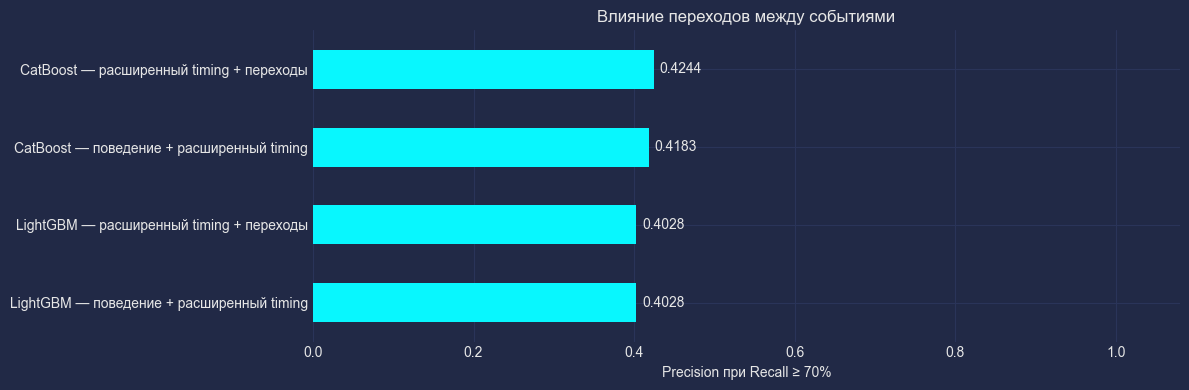

In [112]:
ax = (
    sequence_comparison
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(12, 4),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=4)

ax.set_title("Влияние переходов между событиями")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

### Временная проверка и ограниченный подбор CatBoost

Переходы немного улучшили P@R≥0.7, но снизили Average Precision и ROC-AUC. Проверил оба набора признаков на двух временных разбиениях:

- обучение 6–9 апреля, валидация 10–12 апреля;
- обучение 6–12 апреля, валидация 13–16 апреля.

Сравнил три конфигурации CatBoost. Словарь переходов строил заново только по обучающим кукам каждого разбиения. На этом этапе период 17–19 апреля используется как отложенная проверка. После продолжения исследования он также включён в сравнение вариантов. Поэтому итоговые результаты на трёх периодах рассматриваются как temporal CV, использованная при выборе решения, а не как независимая финальная оценка.

In [113]:
temporal_data = train.merge(
    features[rich_time_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

temporal_folds = [
    {
        "name": "10–12 апреля",
        "valid_start": pd.Timestamp("2026-04-10"),
        "valid_end": pd.Timestamp("2026-04-13"),
    },
    {
        "name": "13–16 апреля",
        "valid_start": pd.Timestamp("2026-04-13"),
        "valid_end": pd.Timestamp("2026-04-17"),
    },
]

catboost_configs = {
    "Текущая": {
        "iterations": 600,
        "depth": 5,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3.0,
    },
    "Мелкие деревья": {
        "iterations": 1000,
        "depth": 4,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5.0,
    },
    "Глубже + регуляризация": {
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 10.0,
    },
}

# Здесь только подсчёт событий внутри каждой куки
# Отбор столбцов будет выполняться отдельно внутри фолдов
all_transition_counts = pd.crosstab(transitions["cookie_id"],transitions["transition"],)

all_transition_totals = (transitions.groupby("cookie_id").size())

temporal_results = []

In [114]:
for fold in temporal_folds:
    fold_fit_mask = (
        temporal_data["window_start_ts"].lt(fold["valid_start"])
        & temporal_data["window_end_ts"].le(fold["valid_start"])
    )

    fold_valid_mask = (
        temporal_data["window_start_ts"].ge(fold["valid_start"])
        & temporal_data["window_start_ts"].lt(fold["valid_end"])
    )

    fold_fit_ids = temporal_data.loc[fold_fit_mask, "cookie_id"]

    # Распространённость переходов - только на обучающей части
    fold_support = (
        transitions.loc[
            transitions["cookie_id"].isin(fold_fit_ids)
        ]
        .groupby("transition")["cookie_id"]
        .nunique()
    )

    fold_transitions = (
        fold_support.loc[fold_support >= 30]
        .index
        .sort_values()
        .to_list()
    )

    fold_counts = all_transition_counts.reindex(
        index=features.index,
        columns=fold_transitions,
        fill_value=0,
    )

    fold_totals = all_transition_totals.reindex(
        features.index,
        fill_value=0,
    )

    fold_transition_features = (
        fold_counts
        .div(fold_totals.where(fold_totals > 0), axis=0)
        .add_prefix("transition_share__")
    )

    fold_transition_features["n_valid_transitions"] = fold_totals
    fold_transition_features.columns.name = None

    fold_data = temporal_data.merge(
        fold_transition_features,
        left_on="cookie_id",
        right_index=True,
        how="left",
    )

    fold_feature_sets = {
        "Timing": rich_time_columns,
        "Timing + переходы": (
            rich_time_columns
            + fold_transition_features.columns.to_list()
        ),
    }

    fold_y_train = fold_data.loc[fold_fit_mask, "target"]
    fold_y_valid = fold_data.loc[fold_valid_mask, "target"]

    print(
        f"\nВалидация: {fold['name']} | "
        f"train: {fold_fit_mask.sum()} | "
        f"valid: {fold_valid_mask.sum()} | "
        f"ботов в valid: {fold_y_valid.sum()}"
    )

    for feature_name, columns in fold_feature_sets.items():
        for config_name, params in catboost_configs.items():
            model = CatBoostClassifier(
                **params,
                loss_function="Logloss",
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                thread_count=4,
            )

            model.fit(
                fold_data.loc[fold_fit_mask, columns],
                fold_y_train,
            )

            scores = model.predict_proba(
                fold_data.loc[fold_valid_mask, columns]
            )[:, 1]

            metric = precision_at_recall(fold_y_valid, scores)

            temporal_results.append({
                "Период": fold["name"],
                "Набор": feature_name,
                "Конфигурация": config_name,
                "Признаков": len(columns),
                "P@R≥0.7": metric,
                "Average Precision": average_precision_score(
                    fold_y_valid, scores
                ),
                "ROC-AUC": roc_auc_score(
                    fold_y_valid, scores
                ),
            })

            print(
                f"{feature_name} | {config_name}: "
                f"P@R≥0.7 = {metric:.4f}"
            )

temporal_results = pd.DataFrame(temporal_results)


Валидация: 10–12 апреля | train: 3305 | valid: 2625 | ботов в valid: 228
Timing | Текущая: P@R≥0.7 = 0.4938
Timing | Мелкие деревья: P@R≥0.7 = 0.4908
Timing | Глубже + регуляризация: P@R≥0.7 = 0.5145
Timing + переходы | Текущая: P@R≥0.7 = 0.4360
Timing + переходы | Мелкие деревья: P@R≥0.7 = 0.4313
Timing + переходы | Глубже + регуляризация: P@R≥0.7 = 0.3837

Валидация: 13–16 апреля | train: 5930 | valid: 3210 | ботов в valid: 248
Timing | Текущая: P@R≥0.7 = 0.4183
Timing | Мелкие деревья: P@R≥0.7 = 0.4193
Timing | Глубже + регуляризация: P@R≥0.7 = 0.4427
Timing + переходы | Текущая: P@R≥0.7 = 0.4244
Timing + переходы | Мелкие деревья: P@R≥0.7 = 0.4350
Timing + переходы | Глубже + регуляризация: P@R≥0.7 = 0.3755


In [115]:
temporal_summary = (
    temporal_results
    .groupby(["Набор", "Конфигурация"])
    .agg(
        precision_mean=("P@R≥0.7", "mean"),
        precision_min=("P@R≥0.7", "min"),
        precision_max=("P@R≥0.7", "max"),
        ap_mean=("Average Precision", "mean"),
        roc_auc_mean=("ROC-AUC", "mean"),
    )
    .sort_values("precision_mean", ascending=False)
)

In [116]:
display(temporal_summary.round(4))

period_comparison = temporal_results.pivot(
    index=["Набор", "Конфигурация"],
    columns="Период",
    values="P@R≥0.7",
)

display(period_comparison.round(4))

precision_mean  precision_min  \
Набор             Конфигурация                                            
Timing            Глубже + регуляризация          0.4786         0.4427   
                  Текущая                         0.4560         0.4183   
                  Мелкие деревья                  0.4550         0.4193   
Timing + переходы Мелкие деревья                  0.4331         0.4313   
                  Текущая                         0.4302         0.4244   
                  Глубже + регуляризация          0.3796         0.3755   

                                          precision_max  ap_mean  roc_auc_mean  
Набор             Конфигурация                                                  
Timing            Глубже + регуляризация         0.5145   0.6745        0.8691  
                  Текущая                        0.4938   0.6768        0.8717  
                  Мелкие деревья                 0.4908   0.6699        0.8718  
Timing + переходы Мелкие деревья                 0.4350   0.6553        0.8624  
                  Текущая                        0.4360   0.6679        0.8664  
                  Глубже + регуляризация         0.3837   0.6612        0.8638

Период                                    10–12 апреля  13–16 апреля
Набор             Конфигурация                                      
Timing            Глубже + регуляризация        0.5145        0.4427
                  Мелкие деревья                0.4908        0.4193
                  Текущая                       0.4938        0.4183
Timing + переходы Глубже + регуляризация        0.3837        0.3755
                  Мелкие деревья                0.4313        0.4350
                  Текущая                       0.4360        0.4244

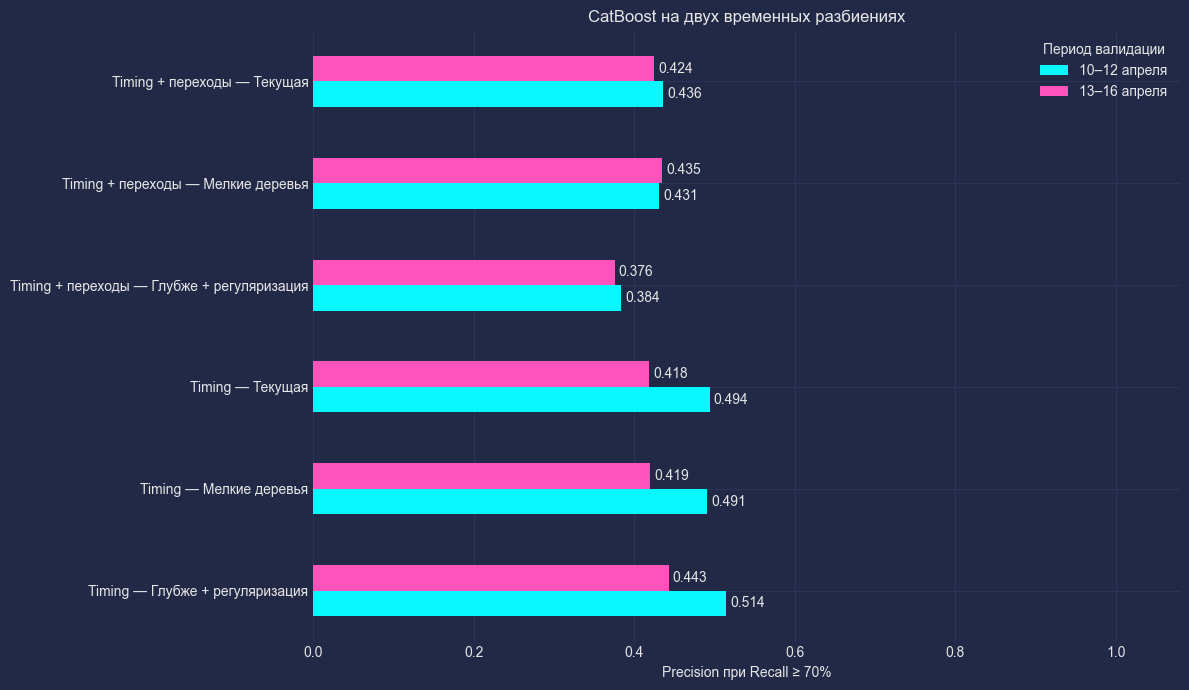

In [117]:
plot_comparison = period_comparison.copy()

plot_comparison.index = [
    f"{feature_set} — {config}"
    for feature_set, config in plot_comparison.index
]

ax = plot_comparison.plot(
    kind="barh",
    figsize=(12, 7),
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.set_title("CatBoost на двух временных разбиениях")
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_ylabel("")
ax.set_xlim(0, 1.08)
ax.legend(title="Период валидации")

plt.tight_layout()
plt.show()

### Промежуточная проверка CatBoost на позднем периоде

На обоих временных разбиениях лучший P@R≥0.7 показал CatBoost на 93 признаках без переходов: depth=6, iterations=1000, learning_rate=0.05, l2_leaf_reg=10.

Среднее качество по двум периодам — 0.4786.
На более позднем периоде результат ниже: 0.4427 против 0.5145.

Фиксирую признаки и параметры. Далее обучаю модель на данных до 17 апреля и оцениваем на отложенном периоде 17–19 апреля.

In [118]:
final_feature_columns = rich_time_columns.copy()

final_params = {
    "iterations": 1000,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 10.0,
    "loss_function": "Logloss",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": 4,
}

final_train_data = train.merge(
    features[final_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

development_mask = (final_train_data["window_start_ts"].lt("2026-04-17") & final_train_data["window_end_ts"].le("2026-04-17"))

final_holdout_mask = (final_train_data["window_start_ts"].ge("2026-04-17"))

X_development = final_train_data.loc[development_mask, final_feature_columns]
y_development = final_train_data.loc[development_mask, "target"]

X_holdout = final_train_data.loc[final_holdout_mask, final_feature_columns]
y_holdout = final_train_data.loc[final_holdout_mask, "target"]

print("Обучение:", X_development.shape)
print("Holdout:", X_holdout.shape)
print("Ботов в holdout:", y_holdout.sum())
print("Доля ботов в holdout:", round(y_holdout.mean(), 4))

Обучение: (9140, 93)
Holdout: (1951, 93)
Ботов в holdout: 160
Доля ботов в holdout: 0.082


In [119]:
holdout_model = CatBoostClassifier(**final_params)

holdout_model.fit(X_development, y_development)

holdout_scores = holdout_model.predict_proba(X_holdout)[:, 1]

holdout_result = pd.DataFrame([{
    "Модель": "CatBoost — 93 признака",
    "P@R≥0.7": precision_at_recall(
        y_holdout, holdout_scores
    ),
    "Average Precision": average_precision_score(
        y_holdout, holdout_scores
    ),
    "ROC-AUC": roc_auc_score(
        y_holdout, holdout_scores
    ),
}])

display(holdout_result.round(4))

,Модель,P@R≥0.7,Average Precision,ROC-AUC
0,CatBoost — 93 признака,0.4634,0.6765,0.8917


In [120]:
precision, recall, thresholds = precision_recall_curve(
    y_holdout,
    holdout_scores,
)

# Последняя точка PR-кривой не имеет соответствующего порога
eligible = np.flatnonzero(recall[:-1] >= 0.7)

best_index = eligible[
    np.argmax(precision[:-1][eligible])
]

holdout_threshold = thresholds[best_index]

holdout_pred = holdout_scores >= holdout_threshold
holdout_labels = y_holdout.to_numpy()

tp = int(((holdout_labels == 1) & holdout_pred).sum())
fp = int(((holdout_labels == 0) & holdout_pred).sum())
fn = int(((holdout_labels == 1) & ~holdout_pred).sum())
tn = int(((holdout_labels == 0) & ~holdout_pred).sum())

display(pd.DataFrame([{
    "Порог на holdout": holdout_threshold,
    "Precision": tp / (tp + fp),
    "Recall": tp / (tp + fn),
    "Найдено ботов": tp,
    "Ложных срабатываний": fp,
    "Пропущено ботов": fn,
    "Верно не отмечено людей": tn,
}]).round(4))

,Порог на holdout,Precision,Recall,Найдено ботов,Ложных срабатываний,Пропущено ботов,Верно не отмечено людей
0,0.096,0.4634,0.7125,114,132,46,1659


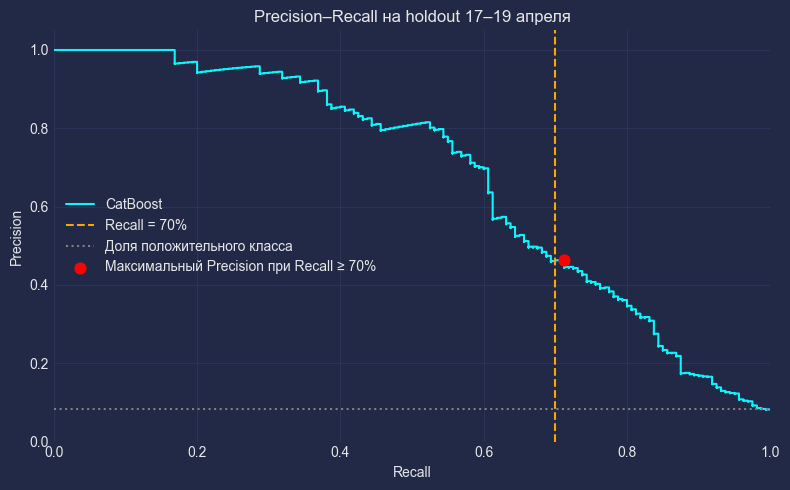

In [121]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.step(
    recall,
    precision,
    where="post",
    label="CatBoost",
)

ax.axvline(
    0.7,
    color="orange",
    linestyle="--",
    label="Recall = 70%",
)

ax.axhline(
    y_holdout.mean(),
    color="gray",
    linestyle=":",
    label="Доля положительного класса",
)

ax.scatter(
    recall[best_index],
    precision[best_index],
    color="red",
    s=60,
    zorder=5,
    label="Максимальный Precision при Recall ≥ 70%",
)

ax.set_title("Precision–Recall на holdout 17–19 апреля")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

### Сессии и короткие всплески активности

Суточные агрегаты могут скрывать локальные серии быстрых действий. Разобивал события куки на сессии: новая сессия начинается после паузы более 30 минут.

Дополнительно считал максимальное количество событий и просмотров объявлений за 1 и 5 минут. Эти признаки должны отражать короткие автоматизированные всплески активности.

In [122]:
session_events = (
    events_clean[
        ["cookie_id", "event_ts", "event_name"]
    ]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

session_events["gap_seconds"] = (
    session_events
    .groupby("cookie_id")["event_ts"]
    .diff()
    .dt.total_seconds()
)

session_events["new_session"] = (
    session_events["gap_seconds"].isna()
    | session_events["gap_seconds"].gt(1800)
)

session_events["session_number"] = (
    session_events
    .groupby("cookie_id")["new_session"]
    .cumsum()
    .astype(int)
)

display(session_events.head(10))

,cookie_id,event_ts,event_name,gap_seconds,new_session,session_number
0,ck_00013fdfa0bd37dd,2026-04-24 18:41:16,photo_swipe,NaN,True,1
1,ck_00013fdfa0bd37dd,2026-04-24 19:16:53,item_view,2137.0,True,2
2,ck_00013fdfa0bd37dd,2026-04-24 19:16:54,photo_swipe,1.0,False,2
3,ck_00013fdfa0bd37dd,2026-04-24 19:17:05,item_view,11.0,False,2
4,ck_00013fdfa0bd37dd,2026-04-24 20:05:05,login,2880.0,True,3
5,ck_00013fdfa0bd37dd,2026-04-24 20:31:33,item_view,1588.0,False,3
6,ck_00013fdfa0bd37dd,2026-04-24 20:34:06,search_results_view,153.0,False,3
7,ck_00013fdfa0bd37dd,2026-04-24 20:36:30,login,144.0,False,3
8,ck_00013fdfa0bd37dd,2026-04-24 20:36:32,contact_chat_open,2.0,False,3
9,ck_00013fdfa0bd37dd,2026-04-24 20:41:33,search_results_view,301.0,False,3


In [123]:
session_stats = (
    session_events
    .groupby(["cookie_id", "session_number"])
    .agg(
        session_start=("event_ts", "min"),
        session_end=("event_ts", "max"),
        session_n_events=("event_ts", "size"),
        session_n_event_types=("event_name", "nunique"),
    )
    .reset_index()
)

session_stats["session_duration_seconds"] = (
    session_stats["session_end"]
    - session_stats["session_start"]
).dt.total_seconds()

session_features = (
    session_stats
    .groupby("cookie_id")
    .agg(
        n_sessions=("session_number", "nunique"),
        session_duration_mean=(
            "session_duration_seconds", "mean"
        ),
        session_duration_median=(
            "session_duration_seconds", "median"
        ),
        session_duration_max=(
            "session_duration_seconds", "max"
        ),
        session_duration_std=(
            "session_duration_seconds", "std"
        ),
        session_events_mean=(
            "session_n_events", "mean"
        ),
        session_events_median=(
            "session_n_events", "median"
        ),
        session_events_max=(
            "session_n_events", "max"
        ),
        session_events_std=(
            "session_n_events", "std"
        ),
        session_event_types_mean=(
            "session_n_event_types", "mean"
        ),
        session_event_types_max=(
            "session_n_event_types", "max"
        ),
    )
)

total_events_by_cookie = (
    session_stats
    .groupby("cookie_id")["session_n_events"]
    .sum()
)

largest_session_events = (
    session_stats
    .groupby("cookie_id")["session_n_events"]
    .max()
)

session_features["largest_session_share"] = (largest_session_events / total_events_by_cookie)

session_features = session_features.reindex(features.index)

session_features["n_sessions"] = (
    session_features["n_sessions"]
    .fillna(0)
    .astype(int)
)

display(session_features.head())

,n_sessions,session_duration_mean,session_duration_median,session_duration_max,session_duration_std,session_events_mean,session_events_median,session_events_max,session_events_std,session_event_types_mean,session_event_types_max,largest_session_share
cookie_id,,,,,,,,,,,,
ck_54a059eb7d3ea68b,1,167.000000,167.0,167.0,NaN,7.000000,7.0,7,NaN,3.000000,3,1.000000
ck_7e4de46eeab82974,7,226.428571,153.0,579.0,192.487105,5.857143,4.0,13,3.891382,3.000000,5,0.317073
ck_9320229ef6304522,7,345.142857,70.0,1957.0,711.775814,5.142857,5.0,10,2.609506,3.428571,6,0.277778
ck_30ccd25bc1714ed9,3,297.000000,392.0,410.0,180.357977,7.000000,8.0,10,3.605551,2.666667,4,0.476190
ck_a77c5f05948cdeef,4,793.750000,271.5,2632.0,1232.267929,7.000000,4.0,19,8.164966,3.000000,6,0.678571


In [124]:
def max_events_in_window(event_times, window_seconds):
    seconds = (
        event_times
        .sort_values()
        .astype("int64")
        .to_numpy()
        / 1_000_000_000
    )

    if len(seconds) == 0:
        return 0

    right_edges = np.searchsorted(
        seconds,
        seconds + window_seconds,
        side="right",
    )

    window_counts = (
        right_edges - np.arange(len(seconds))
    )

    return int(window_counts.max())


burst_rows = []

for cookie_id, cookie_events in events_clean.groupby(
    "cookie_id",
    sort=False,
):
    all_times = cookie_events["event_ts"]

    item_times = cookie_events.loc[
        cookie_events["event_name"].eq("item_view"),
        "event_ts",
    ]

    burst_rows.append({
        "cookie_id": cookie_id,
        "max_events_60s": max_events_in_window(
            all_times,
            60,
        ),
        "max_events_300s": max_events_in_window(
            all_times,
            300,
        ),
        "max_item_views_60s": max_events_in_window(
            item_times,
            60,
        ),
        "max_item_views_300s": max_events_in_window(
            item_times,
            300,
        ),
    })

burst_features = (
    pd.DataFrame(burst_rows)
    .set_index("cookie_id")
    .reindex(features.index)
)

event_counts = (
    events_clean
    .groupby("cookie_id")
    .size()
    .reindex(features.index, fill_value=0)
)

burst_features["max_events_60s_share"] = (
    burst_features["max_events_60s"]
    / event_counts.where(event_counts > 0)
)

burst_features["max_events_300s_share"] = (
    burst_features["max_events_300s"]
    / event_counts.where(event_counts > 0)
)

display(burst_features.head())

,max_events_60s,max_events_300s,max_item_views_60s,max_item_views_300s,max_events_60s_share,max_events_300s_share
cookie_id,,,,,,
ck_54a059eb7d3ea68b,4,7,2,3,0.571429,1.000000
ck_7e4de46eeab82974,4,9,2,6,0.097561,0.219512
ck_9320229ef6304522,5,7,2,2,0.138889,0.194444
ck_30ccd25bc1714ed9,3,8,2,5,0.142857,0.380952
ck_a77c5f05948cdeef,2,8,2,3,0.071429,0.285714


In [125]:
session_features = session_features.join(
    burst_features,
    how="left",
)

session_feature_columns = (
    session_features.columns.to_list()
)

features = pd.concat(
    [
        features.drop(
            columns=session_feature_columns,
            errors="ignore",
        ),
        session_features,
    ],
    axis=1,
).copy()

session_model_columns = (
    rich_time_columns
    + session_feature_columns
)

print("До добавления сессий:", len(rich_time_columns))
print("Новых признаков:", len(session_feature_columns))
print("Всего:", len(session_model_columns))

display(
    pd.DataFrame({
        "Пропуски": session_features.isna().sum(),
        "Доля пропусков, %": (
            session_features.isna().mean() * 100
        ).round(2),
    })
)

До добавления сессий: 93
Новых признаков: 18
Всего: 111


,Пропуски,"Доля пропусков, %"
n_sessions,0,0.00
session_duration_mean,0,0.00
session_duration_median,0,0.00
session_duration_max,0,0.00
session_duration_std,4369,27.31
session_events_mean,0,0.00
session_events_median,0,0.00
session_events_max,0,0.00
session_events_std,4369,27.31
session_event_types_mean,0,0.00


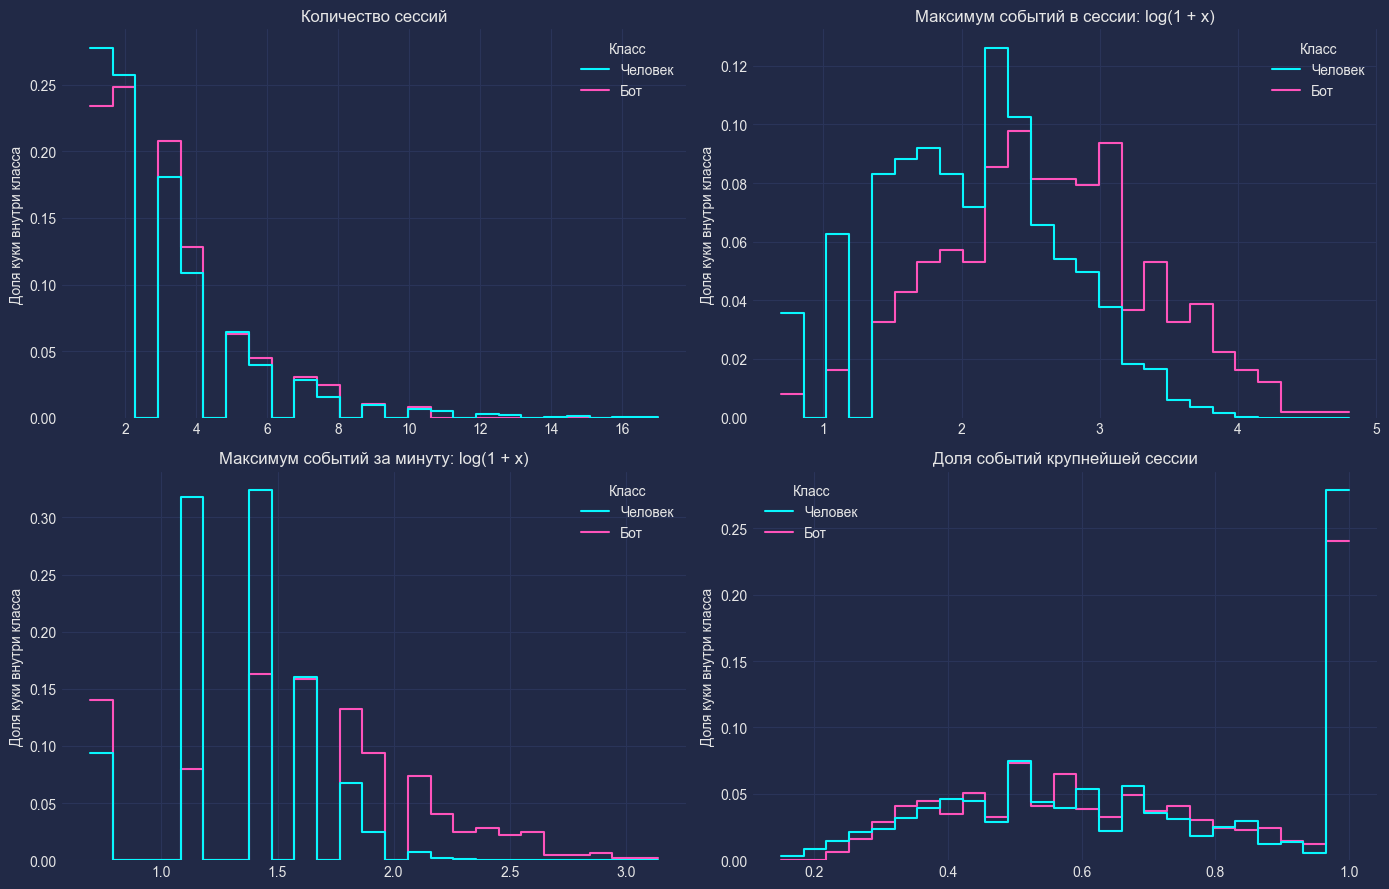

In [126]:
session_plot = train.merge(
    features[session_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

session_plot["Класс"] = session_plot["target"].map({
    0: "Человек",
    1: "Бот",
})

session_plot["log1p_max_events_60s"] = np.log1p(
    session_plot["max_events_60s"]
)

session_plot["log1p_session_events_max"] = np.log1p(
    session_plot["session_events_max"]
)

plot_settings = [
    (
        "n_sessions",
        "Количество сессий",
    ),
    (
        "log1p_session_events_max",
        "Максимум событий в сессии: log(1 + x)",
    ),
    (
        "log1p_max_events_60s",
        "Максимум событий за минуту: log(1 + x)",
    ),
    (
        "largest_session_share",
        "Доля событий крупнейшей сессии",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (column, title) in zip(
    axes.flat,
    plot_settings,
):
    sns.histplot(
        data=session_plot.loc[fit_mask],
        x=column,
        hue="Класс",
        hue_order=["Человек", "Бот"],
        stat="probability",
        common_norm=False,
        bins=25,
        element="step",
        fill=False,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Доля куки внутри класса")

plt.tight_layout()
plt.show()

In [127]:
train_features = train.merge(
    features[session_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[session_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, session_model_columns,]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, session_model_columns]
y_valid = train_features.loc[valid_mask, "target"]

catboost_sessions = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10.0,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — timing + сессии",
    model=catboost_sessions,
    columns=session_model_columns,
)

lgbm_sessions = LGBMClassifier(
    **lgbm_params
)

evaluate_model(
    name="LightGBM — timing + сессии",
    model=lgbm_sessions,
    columns=session_model_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — timing + сессии,111,0.4615,0.6726,0.8829,14.7137


,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LightGBM — timing + сессии,111,0.3452,0.6456,0.8637,1.0461


In [128]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset="Эксперимент",
        keep="last",
    )
    .sort_values(
        "P@R≥0.7",
        ascending=False,
    )
    .reset_index(drop=True)
)

session_experiments = [
    "CatBoost — поведение + расширенный timing",
    "LightGBM — поведение + расширенный timing",
    "CatBoost — timing + сессии",
    "LightGBM — timing + сессии",
]

session_comparison = results_table.loc[
    results_table["Эксперимент"].isin(
        session_experiments
    )
].copy()

display(session_comparison.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — timing + сессии,111,0.4615,0.6726,0.8829,14.7137
2,CatBoost — поведение + расширенный timing,93,0.4183,0.6704,0.8861,4.9601
3,LightGBM — поведение + расширенный timing,93,0.4028,0.6508,0.8690,1.0028
8,LightGBM — timing + сессии,111,0.3452,0.6456,0.8637,1.0461


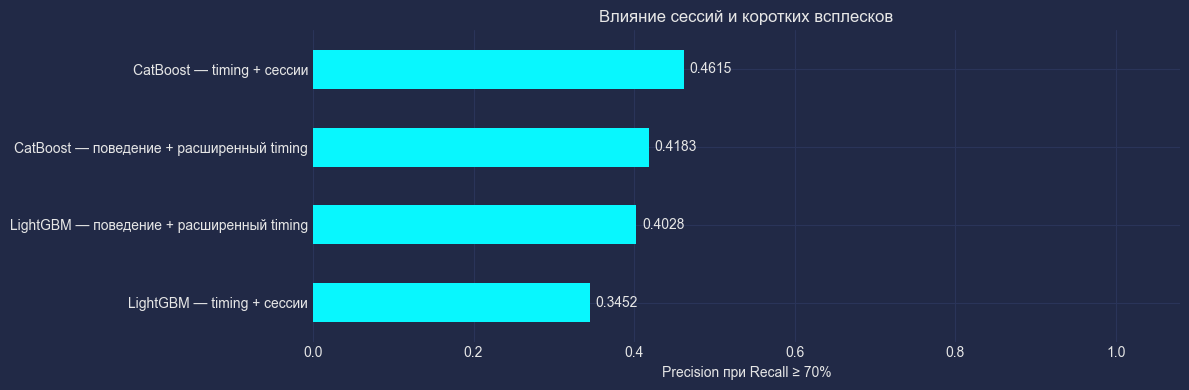

In [129]:
ax = (
    session_comparison
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(12, 4),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=4,
    )

ax.set_title(
    "Влияние сессий и коротких всплесков"
)
ax.set_xlabel(
    "Precision при Recall ≥ 70%"
)
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

У CatBoost в этом сравнении изменились и признаки, и параметры. Поэтому прирост с 0.4183 до 0.4615 нельзя полностью отнести к добавлению сессий. Далее проверял разные границы сессии при одинаковых настройках модели.

### Проверка длительности сессии

В предыдущем эксперименте новая сессия начиналась после паузы более
30 минут. Это рабочая гипотеза, поэтому проверил 3 порога:

- 15 минут;
- 30 минут;
- 60 минут.

Каждый вариант проверял на двух временных разбиениях с одинаковыми параметрами CatBoost.

In [130]:
def build_session_features(session_gap_seconds):
    current_events = (
        events_clean[
            ["cookie_id", "event_ts", "event_name"]
        ]
        .sort_values(["cookie_id", "event_ts"])
        .copy()
    )

    current_events["gap_seconds"] = (
        current_events
        .groupby("cookie_id")["event_ts"]
        .diff()
        .dt.total_seconds()
    )

    current_events["new_session"] = (
        current_events["gap_seconds"].isna()
        | current_events["gap_seconds"].gt(
            session_gap_seconds
        )
    )

    current_events["session_number"] = (
        current_events
        .groupby("cookie_id")["new_session"]
        .cumsum()
        .astype(int)
    )

    current_stats = (
        current_events
        .groupby(["cookie_id", "session_number"])
        .agg(
            session_start=("event_ts", "min"),
            session_end=("event_ts", "max"),
            session_n_events=("event_ts", "size"),
            session_n_event_types=("event_name", "nunique"),
        )
        .reset_index()
    )

    current_stats["session_duration_seconds"] = (
        current_stats["session_end"]
        - current_stats["session_start"]
    ).dt.total_seconds()

    current_features = (
        current_stats
        .groupby("cookie_id")
        .agg(
            n_sessions=("session_number", "nunique"),
            session_duration_mean=(
                "session_duration_seconds", "mean"
            ),
            session_duration_median=(
                "session_duration_seconds", "median"
            ),
            session_duration_max=(
                "session_duration_seconds", "max"
            ),
            session_duration_std=(
                "session_duration_seconds", "std"
            ),
            session_events_mean=(
                "session_n_events", "mean"
            ),
            session_events_median=(
                "session_n_events", "median"
            ),
            session_events_max=(
                "session_n_events", "max"
            ),
            session_events_std=(
                "session_n_events", "std"
            ),
            session_event_types_mean=(
                "session_n_event_types", "mean"
            ),
            session_event_types_max=(
                "session_n_event_types", "max"
            ),
        )
    )

    total_events = (
        current_stats
        .groupby("cookie_id")["session_n_events"]
        .sum()
    )

    largest_session = (
        current_stats
        .groupby("cookie_id")["session_n_events"]
        .max()
    )

    current_features["largest_session_share"] = (
        largest_session / total_events
    )

    current_features = current_features.reindex(
        features.index
    )

    current_features["n_sessions"] = (
        current_features["n_sessions"]
        .fillna(0)
        .astype(int)
    )

    return current_features

In [131]:
session_thresholds = {
    "15 минут": 15 * 60,
    "30 минут": 30 * 60,
    "60 минут": 60 * 60,
}

session_feature_tables = {}

for threshold_name, threshold_seconds in (
    session_thresholds.items()
):
    current_session_features = (
        build_session_features(threshold_seconds)
        .join(burst_features, how="left")
    )

    session_feature_tables[threshold_name] = (
        current_session_features
    )

    print(
        threshold_name,
        "— признаков:",
        current_session_features.shape[1],
    )

15 минут — признаков: 18
30 минут — признаков: 18
60 минут — признаков: 18


In [132]:
threshold_fold_results = []

for threshold_name, current_session_features in (
    session_feature_tables.items()
):
    current_session_columns = (
        current_session_features.columns.to_list()
    )

    current_feature_columns = (
        rich_time_columns
        + current_session_columns
    )

    current_feature_table = pd.concat(
        [
            features[rich_time_columns],
            current_session_features,
        ],
        axis=1,
    )

    current_data = train.merge(
        current_feature_table[current_feature_columns],
        left_on="cookie_id",
        right_index=True,
        how="left",
    )

    for fold in temporal_folds:
        fold_fit_mask = (
            current_data["window_start_ts"]
            .lt(fold["valid_start"])
            & current_data["window_end_ts"]
            .le(fold["valid_start"])
        )

        fold_valid_mask = (
            current_data["window_start_ts"]
            .ge(fold["valid_start"])
            & current_data["window_start_ts"]
            .lt(fold["valid_end"])
        )

        fold_model = CatBoostClassifier(
            iterations=1000,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=10.0,
            loss_function="Logloss",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=4,
        )

        fold_model.fit(
            current_data.loc[
                fold_fit_mask,
                current_feature_columns,
            ],
            current_data.loc[
                fold_fit_mask,
                "target",
            ],
        )

        fold_scores = fold_model.predict_proba(
            current_data.loc[
                fold_valid_mask,
                current_feature_columns,
            ]
        )[:, 1]

        fold_target = current_data.loc[
            fold_valid_mask,
            "target",
        ]

        threshold_fold_results.append({
            "Порог сессии": threshold_name,
            "Период": fold["name"],
            "Признаков": len(current_feature_columns),
            "P@R≥0.7": precision_at_recall(
                fold_target,
                fold_scores,
            ),
            "Average Precision": (
                average_precision_score(
                    fold_target,
                    fold_scores,
                )
            ),
            "ROC-AUC": roc_auc_score(
                fold_target,
                fold_scores,
            ),
        })

threshold_fold_results = pd.DataFrame(
    threshold_fold_results
)

display(
    threshold_fold_results.round(4)
)

,Порог сессии,Период,Признаков,P@R≥0.7,Average Precision,ROC-AUC
0,15 минут,10–12 апреля,111,0.4482,0.6802,0.8531
1,15 минут,13–16 апреля,111,0.3977,0.6654,0.8850
2,30 минут,10–12 апреля,111,0.5000,0.6711,0.8565
3,30 минут,13–16 апреля,111,0.4615,0.6726,0.8829
4,60 минут,10–12 апреля,111,0.4678,0.6725,0.8519
5,60 минут,13–16 апреля,111,0.4372,0.6599,0.8737


In [133]:
threshold_summary = (
    threshold_fold_results
    .groupby("Порог сессии")
    .agg(
        precision_mean=("P@R≥0.7", "mean"),
        precision_min=("P@R≥0.7", "min"),
        precision_max=("P@R≥0.7", "max"),
        ap_mean=("Average Precision", "mean"),
        roc_auc_mean=("ROC-AUC", "mean"),
    )
    .sort_values(
        "precision_mean",
        ascending=False,
    )
)

display(threshold_summary.round(4))

threshold_plot = (
    threshold_fold_results
    .pivot(
        index="Порог сессии",
        columns="Период",
        values="P@R≥0.7",
    )
    .reindex(["15 минут", "30 минут", "60 минут"])
)

,precision_mean,precision_min,precision_max,ap_mean,roc_auc_mean
Порог сессии,,,,,
30 минут,0.4808,0.4615,0.5000,0.6719,0.8697
60 минут,0.4525,0.4372,0.4678,0.6662,0.8628
15 минут,0.4230,0.3977,0.4482,0.6728,0.8690


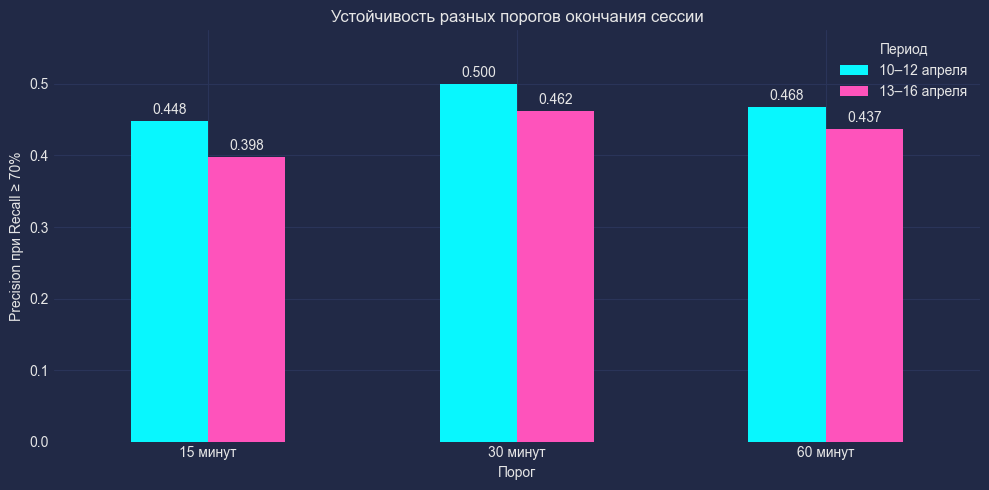

In [134]:
ax = threshold_plot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
    )

ax.set_title(
    "Устойчивость разных порогов окончания сессии"
)
ax.set_xlabel("Порог")
ax.set_ylabel("Precision при Recall ≥ 70%")
ax.legend(title="Период")
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

### Интенсивность взаимодействий и поисковая навигация

Для выбранного порога сессии 30 минут добавил признаки, которые описывают плотность действий вокруг объявлений и поисковых запросов.

Далее проверял:
- длины поисковых запросов;
- повторяемость одного запроса;
- число действий на одно объявление;
- число свайпов и контактов на просмотр объявления;
- переходы на следующую страницу выдачи в рамках одного запроса.

In [135]:
intensity_features = pd.DataFrame(index=features.index)

event_types_for_counts = [
    "item_view",
    "photo_swipe",
    "favorite_add",
    "contact_phone_show",
    "contact_chat_open",
    "contact_message_sent",
    "search_results_view",
]

event_counts_by_type = (
    pd.crosstab(
        events_clean["cookie_id"],
        events_clean["event_name"],
    )
    .reindex(
        index=features.index,
        columns=event_types_for_counts,
        fill_value=0,
    )
)

n_item_views = event_counts_by_type["item_view"]
n_photo_swipes = event_counts_by_type["photo_swipe"]
n_favorites = event_counts_by_type["favorite_add"]
n_search_events = event_counts_by_type["search_results_view"]

n_contact_events = event_counts_by_type[
    [
        "contact_phone_show",
        "contact_chat_open",
        "contact_message_sent",
    ]
].sum(axis=1)

unique_items = (
    events_clean.loc[
        events_clean["event_name"].eq("item_view")
    ]
    .groupby("cookie_id")["item_id"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

intensity_features["item_views_per_unique_item"] = (
    n_item_views
    / unique_items.where(unique_items > 0)
)

intensity_features["photo_swipes_per_item_view"] = (
    n_photo_swipes
    / n_item_views.where(n_item_views > 0)
)

intensity_features["favorites_per_item_view"] = (
    n_favorites
    / n_item_views.where(n_item_views > 0)
)

intensity_features["contacts_per_item_view"] = (
    n_contact_events
    / n_item_views.where(n_item_views > 0)
)

intensity_features["search_events_per_item_view"] = (
    n_search_events
    / n_item_views.where(n_item_views > 0)
)

In [136]:
search_events = (
    events_clean.loc[
        events_clean["event_name"].eq(
            "search_results_view"
        ),
        [
            "cookie_id",
            "event_ts",
            "search_query",
            "search_page",
        ],
    ]
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)

search_events["query_known"] = (
    search_events["search_query"].notna()
    & search_events["search_query"].ne("")
)

search_events["query_length"] = (
    search_events["search_query"]
    .fillna("")
    .str.len()
)

known_queries = search_events.loc[
    search_events["query_known"]
].copy()

query_stats = (
    known_queries
    .groupby("cookie_id")["query_length"]
    .agg(
        [
            "mean",
            "median",
            "std",
            "max",
        ]
    )
)

query_stats.columns = [
    "query_length_mean",
    "query_length_median",
    "query_length_std",
    "query_length_max",
]

intensity_features[query_stats.columns] = query_stats

total_search_events = (
    search_events
    .groupby("cookie_id")
    .size()
    .reindex(features.index, fill_value=0)
)

known_query_events = (
    known_queries
    .groupby("cookie_id")
    .size()
    .reindex(features.index, fill_value=0)
)

n_unique_queries = (
    known_queries
    .groupby("cookie_id")["search_query"]
    .nunique()
    .reindex(features.index, fill_value=0)
)

intensity_features["search_query_known_share"] = (
    known_query_events
    / total_search_events.where(total_search_events > 0)
)

intensity_features["search_events_per_unique_query"] = (
    known_query_events
    / n_unique_queries.where(n_unique_queries > 0)
)

query_counts = (
    known_queries
    .groupby(["cookie_id", "search_query"])
    .size()
)

intensity_features["max_query_repeats"] = (
    query_counts
    .groupby(level=0)
    .max()
)

intensity_features["query_repeat_share"] = (
    (known_query_events - n_unique_queries)
    / known_query_events.where(known_query_events > 0)
)

In [137]:
search_events["previous_query"] = (
    search_events
    .groupby("cookie_id")["search_query"]
    .shift()
)

search_events["previous_page"] = (
    search_events
    .groupby("cookie_id")["search_page"]
    .shift()
)

same_query_pair = (
    search_events["query_known"]
    & search_events["previous_query"].notna()
    & search_events["search_query"].eq(
        search_events["previous_query"]
    )
    & search_events["search_page"].notna()
    & search_events["previous_page"].notna()
)

page_pairs = search_events.loc[
    same_query_pair,
    ["cookie_id", "search_page", "previous_page"],
].copy()

page_pairs["page_delta"] = (
    page_pairs["search_page"]
    - page_pairs["previous_page"]
)

page_pair_features = (
    page_pairs
    .groupby("cookie_id")["page_delta"]
    .agg(
        search_page_pairs="size",
        search_page_increase_share=lambda x: (
            x.gt(0).mean()
        ),
        search_page_decrease_share=lambda x: (
            x.lt(0).mean()
        ),
        search_page_same_share=lambda x: (
            x.eq(0).mean()
        ),
    )
)

intensity_features[
    page_pair_features.columns
] = page_pair_features

page_stats_extra = (
    search_events
    .groupby("cookie_id")["search_page"]
    .agg(
        search_page_std="std",
        search_page_first="first",
        search_page_last="last",
    )
)

intensity_features[
    page_stats_extra.columns
] = page_stats_extra

display(
    pd.DataFrame({
        "Пропуски": intensity_features.isna().sum(),
        "Доля пропусков, %": (
            intensity_features.isna().mean() * 100
        ).round(2),
    })
)

,Пропуски,"Доля пропусков, %"
item_views_per_unique_item,1036,6.48
photo_swipes_per_item_view,1036,6.48
favorites_per_item_view,1036,6.48
contacts_per_item_view,1036,6.48
search_events_per_item_view,1036,6.48
query_length_mean,1356,8.48
query_length_median,1356,8.48
query_length_std,3625,22.66
query_length_max,1356,8.48
search_query_known_share,1356,8.48


In [138]:
session_30_features = (
    session_feature_tables["30 минут"]
)

session_30_columns = (
    session_30_features.columns.to_list()
)

intensity_feature_columns = (
    intensity_features.columns.to_list()
)

features = pd.concat(
    [
        features.drop(
            columns=session_30_columns,
            errors="ignore",
        ),
        session_30_features,
    ],
    axis=1,
).copy()

features = pd.concat(
    [
        features.drop(
            columns=intensity_feature_columns,
            errors="ignore",
        ),
        intensity_features,
    ],
    axis=1,
).copy()

session_30_model_columns = (
    rich_time_columns
    + session_30_columns
)

intensity_model_columns = (
    session_30_model_columns
    + intensity_feature_columns
)

print("Признаков с timing и сессиями:", len(session_30_model_columns))

print("Новых признаков интенсивности:", len(intensity_feature_columns))

print("Всего:", len(intensity_model_columns))

Признаков с timing и сессиями: 111
Новых признаков интенсивности: 20
Всего: 131


In [139]:
train_features = train.merge(
    features[intensity_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[intensity_model_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, intensity_model_columns]
y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, intensity_model_columns]
y_valid = train_features.loc[valid_mask, "target"]

catboost_intensity = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10.0,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — timing + сессии + поиск",
    model=catboost_intensity,
    columns=intensity_model_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — timing + сессии + поиск,131,0.4153,0.6678,0.8838,8.5587


In [140]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset="Эксперимент",
        keep="last",
    )
    .sort_values(
        "P@R≥0.7",
        ascending=False,
    )
    .reset_index(drop=True)
)

search_experiments = [
    "CatBoost — timing + сессии",
    "CatBoost — timing + сессии + поиск",
    "CatBoost — поведение + расширенный timing",
]

search_comparison = results_table.loc[
    results_table["Эксперимент"].isin(
        search_experiments
    )
].copy()

display(search_comparison.round(4))

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — timing + сессии,111,0.4615,0.6726,0.8829,14.7137
2,CatBoost — поведение + расширенный timing,93,0.4183,0.6704,0.8861,4.9601
3,CatBoost — timing + сессии + поиск,131,0.4153,0.6678,0.8838,8.5587


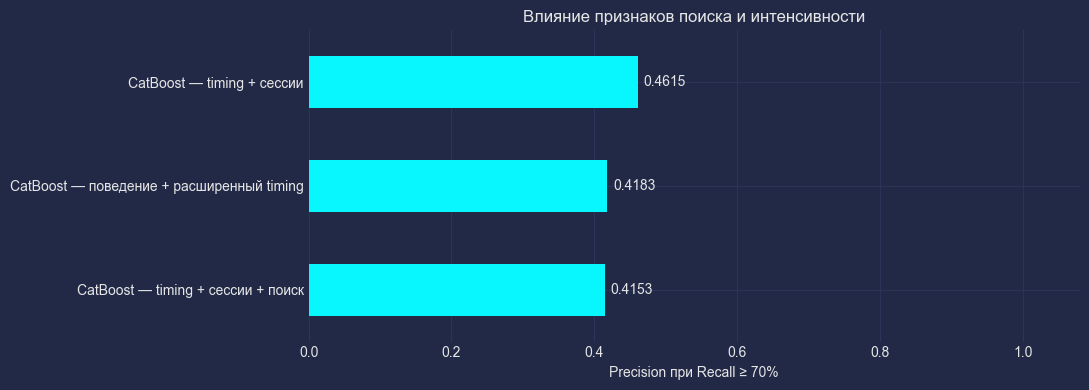

In [141]:
ax = (
    search_comparison
    .sort_values("P@R≥0.7")
    .plot(
        x="Эксперимент",
        y="P@R≥0.7",
        kind="barh",
        figsize=(11, 4),
        legend=False,
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=4,
    )

ax.set_title(
    "Влияние признаков поиска и интенсивности"
)
ax.set_xlabel(
    "Precision при Recall ≥ 70%"
)
ax.set_ylabel("")
ax.set_xlim(0, 1.08)

plt.tight_layout()
plt.show()

### Расширение поведенческих признаков до 189

In [142]:
events_clean["pointer_x"] = pd.to_numeric(
    events_clean["pointer_x"],
    errors="coerce",
)

events_clean["pointer_y"] = pd.to_numeric(
    events_clean["pointer_y"],
    errors="coerce",
)

pointer_raw = (
    events_clean
    .groupby("cookie_id")[["pointer_x", "pointer_y"]]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "max",
        "nunique",
    ])
)

pointer_raw.columns = [
    f"rich_{column}_{stat}"
    for column, stat in pointer_raw.columns
]

pointer_raw = pointer_raw.reindex(features.index)

In [143]:
# Статистики считаем по известным координатам
pointer_present = (events_clean["pointer_x"].notna() & events_clean["pointer_y"].notna())

pointer_present_count = (
    pointer_present
    .groupby(events_clean["cookie_id"])
    .sum()
    .reindex(features.index, fill_value=0)
)

pointer_raw["rich_pointer_present_count"] = (pointer_present_count)

pointer_raw["rich_pointer_ratio"] = (
    pointer_present_count
    / features["n_events"].where(
        features["n_events"] > 0
    )
)

pointer_raw_columns = pointer_raw.columns.tolist()

features = pd.concat(
    [
        features.drop(
            columns=pointer_raw_columns,
            errors="ignore",
        ),
        pointer_raw,
    ],
    axis=1,
).copy()

print("Добавлено признаков курсора:", len(pointer_raw_columns))

display(pointer_raw.head())

Добавлено признаков курсора: 14


,rich_pointer_x_count,rich_pointer_x_mean,rich_pointer_x_std,rich_pointer_x_min,rich_pointer_x_max,rich_pointer_x_nunique,rich_pointer_y_count,rich_pointer_y_mean,rich_pointer_y_std,rich_pointer_y_min,rich_pointer_y_max,rich_pointer_y_nunique,rich_pointer_present_count,rich_pointer_ratio
cookie_id,,,,,,,,,,,,,,
ck_54a059eb7d3ea68b,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0.000000
ck_7e4de46eeab82974,38,917.868421,509.231969,2.0,1907.0,36,38,567.605263,272.953569,104.0,1053.0,38,38,0.926829
ck_9320229ef6304522,35,936.457143,602.124295,35.0,1904.0,35,35,556.657143,312.027426,22.0,1057.0,35,35,0.972222
ck_30ccd25bc1714ed9,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,0.000000
ck_a77c5f05948cdeef,27,978.000000,450.561957,30.0,1791.0,27,27,639.740741,295.966031,5.0,1041.0,27,27,0.964286


In [144]:
def safe_feature_token(value):
    value = str(value).lower().strip()
    value = re.sub(r"[^0-9a-zа-я]+", "_", value)
    return value.strip("_") or "empty"


distribution_parts = []

for column in [
    "platform",
    "item_category",
    "seller_type",
]:
    values_data = events_clean[
        ["cookie_id", column]
    ].copy()

    values_data[column] = (
        values_data[column]
        .fillna("__missing__")
        .astype(str)
    )

    counts = pd.crosstab(
        values_data["cookie_id"],
        values_data[column],
    )

    raw_values = counts.columns.tolist()

    counts = counts.reindex(
        index=features.index,
        fill_value=0,
    )

    counts.columns = [
        f"rich_{column}_count__"
        f"{safe_feature_token(value)}"
        for value in raw_values
    ]

    ratios = counts.div(
        features["n_events"].where(
            features["n_events"] > 0
        ),
        axis=0,
    )

    ratios.columns = [
        column.replace(
            "_count__",
            "_ratio__",
        )
        for column in counts.columns
    ]

    distribution_parts.extend(
        [
            counts,
            ratios,
        ]
    )

rich_distribution_features = pd.concat(
    distribution_parts,
    axis=1,
)

rich_distribution_features.shape

(16000, 44)

In [145]:
rich_distribution_columns = (
    rich_distribution_features.columns.tolist()
)

features = pd.concat(
    [
        features.drop(
            columns=rich_distribution_columns,
            errors="ignore",
        ),
        rich_distribution_features,
    ],
    axis=1,
).copy()

print("Признаков counts/ratios:", len(rich_distribution_columns))

Признаков counts/ratios: 44


In [146]:
rich_global_features = (
    events_clean
    .groupby("cookie_id")
    .agg(
        rich_n_event_types=(
            "event_name",
            "nunique",
        ),
        rich_n_platforms=(
            "platform",
            "nunique",
        ),
        rich_n_categories=(
            "item_category",
            "nunique",
        ),
        rich_n_locations=(
            "item_location",
            "nunique",
        ),
        rich_n_seller_types=(
            "seller_type",
            "nunique",
        ),
        rich_n_items=(
            "item_id",
            "nunique",
        ),
        rich_n_queries=(
            "search_query",
            "nunique",
        ),
        rich_n_user_agents=(
            "user_agent",
            "nunique",
        ),
    )
    .reindex(features.index)
)

rich_global_features["rich_events_per_item"] = (
    features["n_events"]
    / rich_global_features["rich_n_items"]
        .replace(0, np.nan)
)

rich_global_features["rich_events_per_query"] = (
    features["n_events"]
    / rich_global_features["rich_n_queries"]
        .replace(0, np.nan)
)

rich_global_columns = (
    rich_global_features.columns.tolist()
)

features = pd.concat(
    [
        features.drop(
            columns=rich_global_columns,
            errors="ignore",
        ),
        rich_global_features,
    ],
    axis=1,
).copy()

In [147]:
query_events = events_clean.loc[
    events_clean["event_name"].eq("search_results_view")
    & events_clean["search_query"].notna()
    & events_clean["search_query"].ne(""),
    ["cookie_id", "search_query"],
].copy()

query_events["query_length"] = (
    query_events["search_query"].str.len()
)

rich_query_features = (
    query_events.groupby("cookie_id")["query_length"]
    .agg(["mean", "median", "std", "max"])
    .rename(columns=lambda stat: f"rich_query_length_{stat}")
    .reindex(features.index)
)

In [148]:
rich_query_columns = rich_query_features.columns.to_list()

features = pd.concat(
    [
        features.drop(columns=rich_query_columns, errors="ignore"),
        rich_query_features,
    ],
    axis=1,
).copy()

In [149]:
rich_hour_counts = hour_counts.copy()

rich_hour_counts.columns = [
    f"rich_window_hour_count__{hour:02d}"
    for hour in rich_hour_counts.columns
]

rich_hour_count_columns = (
    rich_hour_counts.columns.tolist()
)

features = pd.concat(
    [
        features.drop(
            columns=rich_hour_count_columns,
            errors="ignore",
        ),
        rich_hour_counts,
    ],
    axis=1,
).copy()

In [150]:
rich_feature_columns = list(
    dict.fromkeys(
        rich_time_columns
        + pointer_raw_columns
        + rich_distribution_columns
        + rich_global_columns
        + rich_query_columns
        + rich_hour_count_columns
    )
)

print(
    "Признаков в новом наборе:",
    len(rich_feature_columns),
)

print(
    "Старый набор:",
    len(rich_time_columns),
)

Признаков в новом наборе: 189
Старый набор: 93


In [151]:
train_features = train.merge(
    features[rich_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

test_features = test.merge(
    features[rich_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

X_train = train_features.loc[fit_mask, rich_feature_columns]

y_train = train_features.loc[fit_mask, "target"]

X_valid = train_features.loc[valid_mask, rich_feature_columns]

y_valid = train_features.loc[valid_mask, "target"]

print("Обучение:", X_train.shape)
print("Валидация:", X_valid.shape)

Обучение: (5930, 189)
Валидация: (3210, 189)


In [152]:
catboost_rich = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10.0,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=4,
)

evaluate_model(
    name="CatBoost — rich behavior + timing",
    model=catboost_rich,
    columns=rich_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,CatBoost — rich behavior + timing,189,0.6797,0.7647,0.9327,10.3534


In [153]:
lgbm_rich_params = {
    "n_estimators": 700,
    "learning_rate": 0.035,
    "num_leaves": 31,
    "min_child_samples": 30,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": 4,
    "verbosity": -1,
    "deterministic": True,
    "force_col_wise": True,
}

lgbm_rich = LGBMClassifier(
    **lgbm_rich_params
)

evaluate_model(
    name="LightGBM — rich behavior + timing",
    model=lgbm_rich,
    columns=rich_feature_columns,
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC,"Время, сек"
0,LightGBM — rich behavior + timing,189,0.6932,0.7592,0.9315,1.5863


In [154]:
results_table = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset="Эксперимент",
        keep="last",
    )
    .sort_values(
        "P@R≥0.7",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    results_table[
        [
            "Эксперимент",
            "Признаков",
            "P@R≥0.7",
            "Average Precision",
            "ROC-AUC",
        ]
    ].round(4)
)

,Эксперимент,Признаков,P@R≥0.7,Average Precision,ROC-AUC
0,LightGBM — rich behavior + timing,189,0.6932,0.7592,0.9315
1,CatBoost — rich behavior + timing,189,0.6797,0.7647,0.9327
2,CatBoost — timing + сессии,111,0.4615,0.6726,0.8829
3,CatBoost — расширенный timing + переходы,170,0.4244,0.6636,0.8797
4,CatBoost — поведение + расширенный timing,93,0.4183,0.6704,0.8861
5,CatBoost — timing + сессии + поиск,131,0.4153,0.6678,0.8838
6,LightGBM — поведение + расширенный timing,93,0.4028,0.6508,0.8690
7,LightGBM — расширенный timing + переходы,170,0.4028,0.6541,0.8738
8,CatBoost — базовые + время + разнообразие,56,0.3937,0.6496,0.8697
9,CatBoost — поведение + UA,77,0.3747,0.6490,0.8708


На периоде 13-16 апреля LightGBM на расширенном наборе получил P@R≥0.7 = 0.6932, CatBoost — 0.6797.

По сравнению с ранними экспериментами изменились и состав признаков, и параметры моделей. Поэтому этот результат показывает качество нового варианта в целом, но не выделяет вклад отдельных групп признаков.

### Временная проверка расширенного набора

In [155]:
rich_temporal_data = train.merge(
    features[rich_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

rich_temporal_results = []

print(
    "Размер данных:",
    rich_temporal_data.shape,
)

Размер данных: (11091, 194)


In [156]:
rich_catboost_predictions = {}

for fold in temporal_folds:
    fold_fit_mask = (
        rich_temporal_data["window_start_ts"]
        .lt(fold["valid_start"])
        & rich_temporal_data["window_end_ts"]
        .le(fold["valid_start"])
    )

    fold_valid_mask = (
        rich_temporal_data["window_start_ts"]
        .ge(fold["valid_start"])
        & rich_temporal_data["window_start_ts"]
        .lt(fold["valid_end"])
    )

    X_fit_fold = rich_temporal_data.loc[fold_fit_mask, rich_feature_columns]
    y_fit_fold = rich_temporal_data.loc[fold_fit_mask,"target"]

    X_valid_fold = rich_temporal_data.loc[fold_valid_mask,rich_feature_columns]

    y_valid_fold = rich_temporal_data.loc[fold_valid_mask,"target"]

    rich_catboost_fold = CatBoostClassifier(**final_params)

    rich_catboost_fold.fit(
        X_fit_fold,
        y_fit_fold,
        eval_set=(
            X_valid_fold,
            y_valid_fold,
        ),
        early_stopping_rounds=100,
        verbose=False,
    )

    fold_scores = (
        rich_catboost_fold
        .predict_proba(X_valid_fold)[:, 1]
    )

    rich_catboost_predictions[fold["name"]] = fold_scores

    rich_temporal_results.append({
        "Модель": "CatBoost — rich behavior + timing",
        "Период": fold["name"],
        "Признаков": len(rich_feature_columns),
        "P@R≥0.7": precision_at_recall(
            y_valid_fold,
            fold_scores,
        ),
        "Average Precision": (
            average_precision_score(
                y_valid_fold,
                fold_scores,
            )
        ),
        "ROC-AUC": roc_auc_score(
            y_valid_fold,
            fold_scores,
        ),
        "Лучшая итерация": (
            rich_catboost_fold.get_best_iteration()
        ),
    })

In [157]:
rich_lgbm_predictions = {}

for fold in temporal_folds:
    fold_fit_mask = (
        rich_temporal_data["window_start_ts"]
        .lt(fold["valid_start"])
        & rich_temporal_data["window_end_ts"]
        .le(fold["valid_start"])
    )

    fold_valid_mask = (
        rich_temporal_data["window_start_ts"]
        .ge(fold["valid_start"])
        & rich_temporal_data["window_start_ts"]
        .lt(fold["valid_end"])
    )

    X_fit_fold = rich_temporal_data.loc[fold_fit_mask, rich_feature_columns]
    y_fit_fold = rich_temporal_data.loc[fold_fit_mask, "target"]

    X_valid_fold = rich_temporal_data.loc[fold_valid_mask, rich_feature_columns]
    y_valid_fold = rich_temporal_data.loc[fold_valid_mask, "target"]

    model = LGBMClassifier(
        **lgbm_rich_params
    )

    model.fit(
        X_fit_fold,
        y_fit_fold,
        eval_set=[
            (X_valid_fold, y_valid_fold)
        ],
        callbacks=[
            lgb.early_stopping(
                60,
                verbose=False,
            ),
            lgb.log_evaluation(0),
        ],
    )

    scores = model.predict_proba(
        X_valid_fold
    )[:, 1]

    rich_lgbm_predictions[fold["name"]] = scores

    rich_temporal_results.append({
        "Модель": "LightGBM — rich behavior + timing",
        "Период": fold["name"],
        "Признаков": len(rich_feature_columns),
        "P@R≥0.7": precision_at_recall(
            y_valid_fold,
            scores,
        ),
        "Average Precision": average_precision_score(
            y_valid_fold,
            scores,
        ),
        "ROC-AUC": roc_auc_score(
            y_valid_fold,
            scores,
        ),
        "Лучшая итерация": model.best_iteration_,
    })

    print(fold["name"], "—", round(rich_temporal_results[-1]["P@R≥0.7"], 4))

10–12 апреля — 0.724
13–16 апреля — 0.6877


In [158]:
rich_temporal_results = pd.DataFrame(
    rich_temporal_results
)

display(
    rich_temporal_results.sort_values(
        ["Модель", "Период"]
    ).round(4)
)

rich_temporal_summary = (
    rich_temporal_results
    .groupby("Модель")
    .agg(
        mean_p_at_r70=("P@R≥0.7", "mean"),
        min_p_at_r70=("P@R≥0.7", "min"),
        mean_average_precision=(
            "Average Precision",
            "mean",
        ),
        mean_roc_auc=("ROC-AUC", "mean"),
    )
    .sort_values(
        "mean_p_at_r70",
        ascending=False,
    )
)

display(
    rich_temporal_summary.round(4)
)

,Модель,Период,Признаков,P@R≥0.7,Average Precision,ROC-AUC,Лучшая итерация
0,CatBoost — rich behavior + timing,10–12 апреля,189,0.6867,0.7423,0.9116,336
1,CatBoost — rich behavior + timing,13–16 апреля,189,0.6591,0.7648,0.9327,896
2,LightGBM — rich behavior + timing,10–12 апреля,189,0.7240,0.7558,0.9219,101
3,LightGBM — rich behavior + timing,13–16 апреля,189,0.6877,0.7566,0.9351,151


,mean_p_at_r70,min_p_at_r70,mean_average_precision,mean_roc_auc
Модель,,,,
LightGBM — rich behavior + timing,0.7059,0.6877,0.7562,0.9285
CatBoost — rich behavior + timing,0.6729,0.6591,0.7536,0.9222


### Добавление сессий к расширенному набору

In [159]:
rich_session_feature_columns = list(
    dict.fromkeys(
        rich_feature_columns
        + session_30_columns
    )
)

rich_session_data = train.merge(
    features[rich_session_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

print("Признаков rich:", len(rich_feature_columns))

print("Признаков rich + sessions:", len(rich_session_feature_columns))

Признаков rich: 189
Признаков rich + sessions: 207


In [160]:
rich_session_results = []

for fold in temporal_folds:
    fold_fit_mask = (
        rich_session_data["window_start_ts"]
        .lt(fold["valid_start"])
        & rich_session_data["window_end_ts"]
        .le(fold["valid_start"])
    )

    fold_valid_mask = (
        rich_session_data["window_start_ts"]
        .ge(fold["valid_start"])
        & rich_session_data["window_start_ts"]
        .lt(fold["valid_end"])
    )

    X_fit_fold = rich_session_data.loc[fold_fit_mask, rich_session_feature_columns]
    y_fit_fold = rich_session_data.loc[fold_fit_mask, "target"]

    X_valid_fold = rich_session_data.loc[fold_valid_mask, rich_session_feature_columns]
    y_valid_fold = rich_session_data.loc[fold_valid_mask, "target"]

    model = LGBMClassifier(
        **lgbm_rich_params
    )

    model.fit(
        X_fit_fold,
        y_fit_fold,
        eval_set=[
            (X_valid_fold, y_valid_fold)
        ],
        callbacks=[
            lgb.early_stopping(
                60,
                verbose=False,
            ),
            lgb.log_evaluation(0),
        ],
    )

    scores = model.predict_proba(
        X_valid_fold
    )[:, 1]

    rich_session_results.append({
        "Период": fold["name"],
        "P@R≥0.7": precision_at_recall(
            y_valid_fold,
            scores,
        ),
        "Average Precision": (
            average_precision_score(
                y_valid_fold,
                scores,
            )
        ),
        "ROC-AUC": roc_auc_score(
            y_valid_fold,
            scores,
        ),
        "Лучшая итерация": model.best_iteration_,
    })

    print(fold["name"], "—", round(rich_session_results[-1]["P@R≥0.7"], 4))

10–12 апреля — 0.7583
13–16 апреля — 0.6471


In [161]:
rich_session_results = pd.DataFrame(
    rich_session_results
)

display(
    rich_session_results.round(4)
)

display(
    rich_session_results[
        [
            "P@R≥0.7",
            "Average Precision",
            "ROC-AUC",
        ]
    ]
    .mean()
    .to_frame("Среднее")
    .T
    .round(4)
)

,Период,P@R≥0.7,Average Precision,ROC-AUC,Лучшая итерация
0,10–12 апреля,0.7583,0.7600,0.9225,103
1,13–16 апреля,0.6471,0.7534,0.9377,148


,P@R≥0.7,Average Precision,ROC-AUC
Среднее,0.7027,0.7567,0.9301


Добавление сессий к 189 признакам не улучшило среднее качество: 0.7027 против 0.7059. На первом периоде результат вырос, на втором снизился. В итоговый набор этот блок не включал.

### Усреднение предсказаний LightGBM и CatBoost

In [162]:
blend_results = []

for lgb_weight in np.arange(
    0.0,
    1.01,
    0.1,
):
    fold_metrics = []

    for fold in temporal_folds:
        fold_valid_mask = (
            rich_temporal_data["window_start_ts"]
            .ge(fold["valid_start"])
            & rich_temporal_data["window_start_ts"]
            .lt(fold["valid_end"])
        )

        y_valid_fold = rich_temporal_data.loc[
            fold_valid_mask,
            "target",
        ]

        lgb_scores = (rich_lgbm_predictions[fold["name"]])
        catboost_scores = (rich_catboost_predictions[fold["name"]])

        blended_scores = (
            lgb_weight * lgb_scores
            + (1 - lgb_weight) * catboost_scores
        )

        fold_metrics.append(
            precision_at_recall(
                y_valid_fold,
                blended_scores,
            )
        )

    blend_results.append({
        "Вес LightGBM": lgb_weight,
        "Вес CatBoost": 1 - lgb_weight,
        "Средний P@R≥0.7": np.mean(
            fold_metrics
        ),
        "Минимальный P@R≥0.7": np.min(
            fold_metrics
        ),
    })

blend_results = pd.DataFrame(blend_results)

display(
    blend_results.sort_values(
        "Средний P@R≥0.7",
        ascending=False,
    ).round(4)
)

,Вес LightGBM,Вес CatBoost,Средний P@R≥0.7,Минимальный P@R≥0.7
5,0.5,0.5,0.7381,0.7250
4,0.4,0.6,0.7351,0.7190
6,0.6,0.4,0.7351,0.7190
7,0.7,0.3,0.7336,0.7160
8,0.8,0.2,0.7304,0.7131
3,0.3,0.7,0.7229,0.7073
2,0.2,0.8,0.7192,0.7045
9,0.9,0.1,0.7167,0.6960
10,1.0,0.0,0.7059,0.6877
1,0.1,0.9,0.6967,0.6824


### Сравнение усреднения оценок и рангов

In [163]:
rank_blend_predictions = {}
rank_comparison_rows = []

for fold in temporal_folds:
    fold_name = fold["name"]

    fold_valid_mask = (
        (rich_temporal_data["window_start_ts"] >= fold["valid_start"])
        & (rich_temporal_data["window_start_ts"] < fold["valid_end"])
    )

    y_fold = rich_temporal_data.loc[fold_valid_mask, "target"].to_numpy()

    pred_lgbm = np.asarray(rich_lgbm_predictions[fold_name])
    pred_catboost = np.asarray(rich_catboost_predictions[fold_name])

    lgbm_rank = pd.Series(pred_lgbm).rank(
        method="average",
        pct=True,
    ).to_numpy()

    catboost_rank = pd.Series(pred_catboost).rank(
        method="average",
        pct=True,
    ).to_numpy()

    probability_blend = (
        0.5 * pred_lgbm
        + 0.5 * pred_catboost
    )

    rank_blend = (
        0.5 * lgbm_rank
        + 0.5 * catboost_rank
    )

    rank_blend_predictions[fold_name] = rank_blend

    rank_comparison_rows.extend([
        {
            "fold": fold_name,
            "variant": "probability blend",
            "p_at_recall_70": precision_at_recall(
                y_fold,
                probability_blend,
            ),
        },
        {
            "fold": fold_name,
            "variant": "rank blend",
            "p_at_recall_70": precision_at_recall(
                y_fold,
                rank_blend,
            ),
        },
    ])

In [164]:
rank_comparison = (
    pd.DataFrame(rank_comparison_rows)
    .groupby("variant")["p_at_recall_70"]
    .agg(
        mean="mean",
        minimum="min",
    )
    .sort_values("mean", ascending=False)
)

display(rank_comparison)

,mean,minimum
variant,,
probability blend,0.738087,0.725000
rank blend,0.723229,0.698795


Усреднение оценок LightGBM и CatBoost дало средний P@R≥0.7 = 0.7381 на двух периодах. Усреднение рангов оказалось хуже — 0.7232. Для дальнейших сравнений использовал именно усреднение оценок.

### Доли конкретных User-Agent

Ранее проверялись обобщённые признаки браузера и операционной системы. Теперь для каждой куки считал доли событий с конкретными User-Agent, это другое представление UA. И оно может различать известные клиенты, но сильнее зависит от их состава и версий.

In [165]:
ua_source = (
    events_clean["user_agent"]
    .astype("string")
    .fillna("__MISSING__")
)

ua_counts = pd.crosstab(
    events_clean["cookie_id"],
    ua_source,
)

ua_feature_columns = [
    f"ua_ratio__{i}"
    for i in range(ua_counts.shape[1])
]

ua_counts.columns = ua_feature_columns

ua_ratios = (
    ua_counts
    .div(
        features["n_events"].replace(0, np.nan),
        axis=0,
    )
    .fillna(0)
)

features = features.drop(
    columns=ua_feature_columns,
    errors="ignore",
)

features = features.join(
    ua_ratios,
    how="left",
)

features[ua_feature_columns] = (
    features[ua_feature_columns]
    .fillna(0)
)

print("Количество UA-признаков:", len(ua_feature_columns))

Количество UA-признаков: 148


In [166]:
rich_ua_feature_columns = list(
    dict.fromkeys(
        rich_feature_columns
        + ua_feature_columns
    )
)

rich_ua_data = train.merge(
    features[rich_ua_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

# Нули нужны только для UA-долей: отсутствие конкретного User-Agent означает долю 0
rich_ua_data[ua_feature_columns] = (
    rich_ua_data[ua_feature_columns]
    .fillna(0)
)

print(
    "Количество признаков:",
    len(rich_ua_feature_columns),
)

print(
    "Пропуски в rich-признаках:",
    rich_ua_data[rich_feature_columns]
    .isna()
    .sum()
    .sum(),
)

Количество признаков: 337
Пропуски в rich-признаках: 90886


### Взвешенный LightGBM и ансамбль на трёх временных разбиениях

In [167]:
ua_temporal_folds = [
    {
        "name": "10–12 апреля",
        "valid_start": pd.Timestamp("2026-04-10"),
        "valid_end": pd.Timestamp("2026-04-13"),
    },
    {
        "name": "13–16 апреля",
        "valid_start": pd.Timestamp("2026-04-13"),
        "valid_end": pd.Timestamp("2026-04-17"),
    },
    {
        "name": "17–19 апреля",
        "valid_start": pd.Timestamp("2026-04-17"),
        "valid_end": pd.Timestamp("2026-04-20"),
    },
]

In [168]:
ua_params_1 = lgbm_rich_params.copy()
ua_params_1.update({
    "scale_pos_weight": 3.0,
    "colsample_bytree": 0.85,
    "min_child_samples": 30,
})

ua_params_2 = ua_params_1.copy()
ua_params_2["colsample_bytree"] = 0.70

ua_params_3 = ua_params_1.copy()
ua_params_3["min_child_samples"] = 15

ua_param_sets = {
    "spw3_c85_leaf30": ua_params_1,
    "spw3_c70_leaf30": ua_params_2,
    "spw3_c85_leaf15": ua_params_3,
}

In [169]:
def fit_temporal_lgbm(
    data,
    feature_columns,
    folds,
    params,
):
    predictions = {}
    score_rows = []
    best_iterations = {}

    for fold in folds:
        fold_name = fold["name"]

        # К началу валидации обучающие окна должны быть завершены
        train_mask = (
            (data["window_start_ts"] < fold["valid_start"])
            & (data["window_end_ts"] <= fold["valid_start"])
        )

        valid_mask = (
            (data["window_start_ts"] >= fold["valid_start"])
            & (data["window_start_ts"] < fold["valid_end"])
        )

        model = LGBMClassifier(**params)

        # Раннюю остановку делаем по logloss, варианты сравниваем по P@R≥0.7
        model.fit(
            data.loc[train_mask, feature_columns],
            data.loc[train_mask, "target"],
            eval_set=[
                (
                    data.loc[valid_mask, feature_columns],
                    data.loc[valid_mask, "target"],
                )
            ],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(60, verbose=False),
            ],
        )

        fold_prediction = model.predict_proba(
            data.loc[valid_mask, feature_columns],
            num_iteration=model.best_iteration_,
        )[:, 1]

        predictions[fold_name] = fold_prediction

        score_rows.append({
            "fold": fold_name,
            "p_at_recall_70": precision_at_recall(
                data.loc[valid_mask, "target"],
                fold_prediction,
            ),
            "best_iteration": model.best_iteration_,
        })

        best_iterations[fold_name] = model.best_iteration_

    return (
        predictions,
        pd.DataFrame(score_rows),
        best_iterations,
    )

In [170]:
ua_predictions = {}
ua_score_tables = []
ua_best_iterations = {}

for model_name, params in ua_param_sets.items():
    predictions, scores, best_iterations = fit_temporal_lgbm(
        rich_ua_data,
        rich_ua_feature_columns,
        ua_temporal_folds,
        params,
    )

    ua_predictions[model_name] = predictions
    ua_best_iterations[model_name] = best_iterations

    scores["model"] = model_name
    ua_score_tables.append(scores)

ua_scores = pd.concat(
    ua_score_tables,
    ignore_index=True,
)

In [171]:
ua_summary = (
    ua_scores
    .groupby("model")["p_at_recall_70"]
    .agg(
        mean="mean",
        minimum="min",
    )
    .sort_values("mean", ascending=False)
)

display(ua_summary)

,mean,minimum
model,,
spw3_c85_leaf15,0.759207,0.725000
spw3_c70_leaf30,0.745925,0.728033
spw3_c85_leaf30,0.739350,0.696000


In [172]:
ua_ensemble_predictions = {}
ua_ensemble_rows = []

model_names = list(ua_param_sets)

for fold in ua_temporal_folds:
    fold_name = fold["name"]

    valid_mask = (
        (rich_ua_data["window_start_ts"] >= fold["valid_start"])
        & (rich_ua_data["window_start_ts"] < fold["valid_end"])
    )

    y_valid = rich_ua_data.loc[
        valid_mask,
        "target",
    ].to_numpy()

    fold_prediction = np.mean(
        [
            ua_predictions[model_name][fold_name]
            for model_name in model_names
        ],
        axis=0,
    )

    ua_ensemble_predictions[fold_name] = fold_prediction

    ua_ensemble_rows.append({
        "fold": fold_name,
        "p_at_recall_70": precision_at_recall(
            y_valid,
            fold_prediction,
        ),
    })

ua_ensemble_scores = pd.DataFrame(
    ua_ensemble_rows,
)

display(ua_ensemble_scores)

,fold,p_at_recall_70
0,10–12 апреля,0.761905
1,13–16 апреля,0.737288
2,17–19 апреля,0.800000


In [173]:
print(
    "Средний P@R≥0.7:",
    ua_ensemble_scores["p_at_recall_70"].mean(),
)

print(
    "Минимальный P@R≥0.7:",
    ua_ensemble_scores["p_at_recall_70"].min(),
)

Средний P@R≥0.7: 0.7663976324993275
Минимальный P@R≥0.7: 0.7372881355932204


## Итоги исследования

Выбран равный ансамбль трёх LightGBM на 337 признаках: 189 поведенческих и временных признаков и 148 долей User-Agent.

Результаты P@R≥0.7:
- 10–12 апреля: 0.7619;
- 13–16 апреля: 0.7373;
- 17–19 апреля: 0.8000.

Среднее — 0.7664, минимум — 0.7373. Ансамбль превысил среднее и минимальное качество каждого из трёх входящих в него вариантов.

На первых двух периодах итоговый ансамбль LightGBM получил в среднем 0.7496. У ансамбля LightGBM и CatBoost на тех же периодах было 0.7381. Среднее 0.7664 относится уже к трём периодам, включая 17–19 апреля.

Пропуски в статистических признаках сохранены. Нулями заполняются счётчики отсутствующих событий и доли отсутствующих категорий, когда это соответствует смыслу признака.

Периоды валидации использовались при выборе решения. Результаты характеризуют локальную валидацию и не гарантируют такое же качество на скрытом тесте. Возможное ограничение — зависимость признаков UA и координат от состава клиентов и особенностей интерфейса.

In [174]:
ua_final_iterations = {}

# Для полного обучения брал медиану лучших итераций по временным разбиениям
for model_name, fold_iterations in ua_best_iterations.items():
    ua_final_iterations[model_name] = int(
        np.median(
            list(fold_iterations.values())
        )
    )

display(
    pd.Series(
        ua_final_iterations,
        name="n_estimators",
    )
)

spw3_c85_leaf30    168
spw3_c70_leaf30    183
spw3_c85_leaf15    187
Name: n_estimators, dtype: int64

In [175]:
test_ua_data = test.merge(
    features[rich_ua_feature_columns],
    left_on="cookie_id",
    right_index=True,
    how="left",
)

# Заполнял только UA-признаки, пропуски в rich-признаках сохранял
test_ua_data[ua_feature_columns] = (
    test_ua_data[ua_feature_columns]
    .fillna(0)
)

X_full_ua = rich_ua_data[
    rich_ua_feature_columns
]

y_full_ua = rich_ua_data["target"]

X_test_ua = test_ua_data[
    rich_ua_feature_columns
]

In [176]:
final_ua_models = {}
final_ua_test_predictions = {}

for model_name, params in ua_param_sets.items():
    full_fit_params = params.copy()
    full_fit_params["n_estimators"] = ua_final_iterations[model_name]
    
    model = LGBMClassifier(**full_fit_params)

    model.fit(
        X_full_ua,
        y_full_ua,
    )

    final_ua_models[model_name] = model

    final_ua_test_predictions[model_name] = (
        model.predict_proba(X_test_ua)[:, 1]
    )

In [177]:
test_score = np.mean(
    list(final_ua_test_predictions.values()),
    axis=0,
)

test_score = np.clip(
    test_score,
    0,
    1,
)

submission = pd.DataFrame({
    "cookie_id": test["cookie_id"],
    "score": test_score,
})

submission.to_csv(
    "submission.csv",
    index=False,
)

submission.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.002912
1,ck_a76ee3b3e3e522fd,0.266138
2,ck_94c9a4d382689e82,0.124187
3,ck_8eaf9509ad9462a0,0.002253
4,ck_9a88a5a989cb5bc6,0.022633


In [178]:
print("Колонки:", submission.columns.tolist())
print("Размер:", submission.shape)
print("Дубликаты cookie_id:", submission["cookie_id"].duplicated().sum())
print("Пропуски score:", submission["score"].isna().sum())
print("Диапазон score:", submission["score"].min(), submission["score"].max())

Колонки: ['cookie_id', 'score']
Размер: (4909, 2)
Дубликаты cookie_id: 0
Пропуски score: 0
Диапазон score: 0.001212983576653103 0.9946349402021184
